## Scenario 11 — Agentic AI for Circular Single (Eff)

- Framework: Multi-agent
- Decision making: **Gemini** (per-tier LLM calls), **strict JSON schema enforced**.
- Agents pick **discrete policy knobs** only: `alpha`, `service_level`, `expedite`.
- All inventory/forecast math remains **deterministic in code**.
- Linear forward chain; asymmetric info via **degraded observations**.


In [1]:
# ===== G2 — Setup =====
!pip -q install jsonschema google-generativeai

import os, json
from getpass import getpass

# 1) Read API key
if "GEMINI_API_KEY" not in os.environ or not os.environ["GEMINI_API_KEY"]:
    os.environ["GEMINI_API_KEY"] = getpass("Enter GEMINI_API_KEY: ")

# 2) Bypass any local proxies that may force localhost routing
for var in ["HTTP_PROXY","HTTPS_PROXY","ALL_PROXY","NO_PROXY","http_proxy","https_proxy","all_proxy","no_proxy"]:
    if var in os.environ:
        os.environ.pop(var, None)
# (Optional belt-and-suspenders)
os.environ["NO_PROXY"] = "*"

# 3) Configure client with explicit endpoint
import google.generativeai as genai
genai.configure(
    api_key=os.environ["GEMINI_API_KEY"],
    client_options={"api_endpoint": "https://generativelanguage.googleapis.com"}
)

# 4) Imports
import numpy as np
from dataclasses import dataclass
from typing import Dict, Any, List
from jsonschema import validate, ValidationError

# 5) Test
try:
    mdl = genai.GenerativeModel("gemini-1.5-flash")
    resp = mdl.generate_content("Return the single word: OK", request_options={"timeout": 6})
    print("Smoke test:", (resp.text or "").strip())
except Exception as e:
    print(" Test:", repr(e))

print("Setup complete.")


Enter GEMINI_API_KEY: ··········
Smoke test: OK
Setup complete.


In [2]:
# ===== R1 — Roles, profiles, project, disruption, InfoBank (CLOSED LOOP - GLOBAL) =====
from dataclasses import dataclass, field
from typing import Dict, Any, List, Optional
import numpy as np

rng = np.random.default_rng(42)
horizonWeeks = 52

# Project demand (units per week)
customerDemand = np.array([
    0, 4, 0, 0, 1, 3, 1, 1, 7, 1,
    1, 4, 9, 3, 5, 1, 2, 12, 1, 0,
    6, 1, 1, 1, 1, 1, 2, 1, 4, 2,
    7, 1, 0, 0, 1, 4, 5, 0, 2, 0,
    0, 1, 1, 1, 1, 0, 1, 0,
    0, 0, 0, 0
])

# Project waste generation pattern (renovation - early demolition creates waste for later construction)
projectWaste = np.array([
    # Early demolition phase - modest bump
    3, 4, 3, 3, 2, 2, 2, 2,
    # Construction phase - steady but moderate
    2, 3, 2, 3, 2, 3, 2, 2, 3, 2, 3, 2,
    # Upper structure - tapering
    2, 2, 2, 1, 2, 1, 2, 2, 1, 1, 1, 1,
    # Final phase - minimal
    1, 1, 1, 1, 1, 0, 1, 0,
    # Completion - almost none
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
], dtype=float)

# Ensure both arrays have exactly 52 elements
assert len(customerDemand) == 52, f"customerDemand has {len(customerDemand)} elements, need 52"
assert len(projectWaste) == 52, f"projectWaste has {len(projectWaste)} elements, need 52"

# ---- Closed-loop supply chain structure ----
ROLES = ["Sub", "PO", "3PL", "Dist", "Sup", "CollPoint", "MatRecov"]
FLOW = {
   # Forward chain
   "Sup": "Dist", "Dist": "3PL", "3PL": "PO", "PO": "Sub",
   # Reverse chain (waste flow)
   "Sub": "CollPoint", "CollPoint": "MatRecov", "MatRecov": "Sup"
}

NEIGHBORS = {
   "Sub": ["PO", "CollPoint"],  # Sub connects to PO (forward) and CollPoint (waste)
   "PO": ["Sub", "3PL"],
   "3PL": ["PO", "Dist"],
   "Dist": ["3PL", "Sup"],
   "Sup": ["Dist", "MatRecov"],  # Sup receives from Dist (forward) and MatRecov (recovered materials)
   "CollPoint": ["Sub", "MatRecov"],
   "MatRecov": ["CollPoint", "Sup"]
}

@dataclass
class Profile:
   name: str
   policy_version: int = 0
   share_keys: List[str] = field(default_factory=list)

profiles: Dict[str, Profile] = {
   "Sub": Profile("Sub", share_keys=["backlog"]),
   "PO": Profile("PO", share_keys=["backlog", "pipeline"]),
   "3PL": Profile("3PL", share_keys=["pipeline"]),
   "Dist": Profile("Dist", share_keys=["on_hand", "backlog"]),
   "Sup": Profile("Sup", share_keys=["on_hand", "pipeline"]),
   "CollPoint": Profile("CollPoint", share_keys=["on_hand"]),
   "MatRecov": Profile("MatRecov", share_keys=["on_hand", "pipeline"]),
}

# Project info
project = {"id": "P1", "material": "Rebar#5", "type": "renovation"}

disruption = {
   "week": 30,
   "delta_leadtime": 2,
   "duration_weeks": 8,
}

# Recovery parameters
RECOVERY_RATE = 0.90  # 90% of waste can be recovered
RECOVERY_LEAD_TIME = 3  # 3 weeks to process waste into usable materials

# Noise parameter
leadtime_noise = 0.0

def degrade_obs(x: float, rel_std: float, rng) -> float:
   return float(max(0.0, x * (1.0 + rng.normal(0.0, rel_std))))

class InfoBank:
   def __init__(self, profiles: Dict[str, Profile], rng, info_regime: str = "global"):
       if info_regime not in ["local", "global"]:
           raise ValueError("info_regime must be 'local' or 'global'")
       self.profiles = profiles
       self.rng = rng
       self.info_regime = info_regime
       self.local: Dict[str, Dict[str, Any]] = {r: {} for r in ROLES}

       # Shared data structure depends on regime
       if info_regime == "local":
           self.shared: Dict[str, Dict[str, Dict[str, Any]]] = {
               role: {neighbor: {} for neighbor in NEIGHBORS.get(role, [])}
               for role in ROLES
           }
       else:
           self.shared: Dict[str, Dict[str, Any]] = {r: {} for r in ROLES}

       self.true_lead: Dict[str, int] = {
           # Forward chain lead times
           "Sup->Dist": 3,
           "Dist->3PL": 1,
           "3PL->PO": 1,
           "PO->Sub": 0,
           # Reverse chain lead times
           "Sub->CollPoint": 1,
           "CollPoint->MatRecov": 2,
           "MatRecov->Sup": RECOVERY_LEAD_TIME
       }
       self.time = 0

   def apply_disruption(self, t: int):
       if t == disruption["week"]:
           self.true_lead["Sup->Dist"] += disruption["delta_leadtime"]
       if t == disruption["week"] + disruption["duration_weeks"]:
           self.true_lead["Sup->Dist"] -= disruption["delta_leadtime"]

   def update_share_policy(self, role: str, add_keys: Optional[List[str]] = None, drop_keys: Optional[List[str]] = None):
       p = self.profiles[role]
       if add_keys:
           for k in add_keys:
               if k not in p.share_keys and k in ["on_hand", "backlog", "pipeline"]:
                   p.share_keys.append(k)
       if drop_keys:
           p.share_keys = [k for k in p.share_keys if k not in drop_keys]
       p.policy_version += 1

   def publish(self, role: str):
       """Publish information according to the information regime"""
       policy_keys = set(self.profiles[role].share_keys)
       shared_data = {k: self.local[role].get(k) for k in policy_keys if k in self.local[role]}

       if self.info_regime == "local":
           neighbors = NEIGHBORS.get(role, [])
           for neighbor in neighbors:
               if neighbor in ROLES:
                   if neighbor not in self.shared:
                       self.shared[neighbor] = {}
                   self.shared[neighbor][role] = shared_data.copy()
       else:
           self.shared[role] = shared_data.copy()

   def context_view_for(self, role: str) -> Dict[str, Any]:
       view = {
           "role": role,
           "t": self.time,
           "project_id": project["id"],
           "material": project["material"],
           "project_type": project["type"]
       }
       view[f"{role}_self"] = {k: self.local[role].get(k) for k in self.local[role].keys()}

       if self.info_regime == "local":
           visible_roles = NEIGHBORS.get(role, [])
           for neighbor_role in visible_roles:
               neighbor_shared_data = self.shared.get(role, {}).get(neighbor_role, {})
               view[f"{neighbor_role}_shared"] = neighbor_shared_data
       else:
           visible_roles = [r for r in ROLES if r != role]
           for r in visible_roles:
               view[f"{r}_shared"] = self.shared.get(r, {}).copy()

       view["my_profile"] = {"policy_version": self.profiles[role].policy_version}
       view["info_regime_context"] = {
           "regime": self.info_regime,
           "visible_roles": visible_roles,
           "total_network_size": len(ROLES)
       }
       return view

   def _get_shared_insights(self, role: str) -> Dict[str, float]:
       """Aggregated insights from shared information"""
       downstream_backlog = 0.0
       upstream_inventory = 0.0
       visible_partners = []

       # Extended chain order for closed loop
       chain_order = {"Sup": 0, "Dist": 1, "3PL": 2, "PO": 3, "Sub": 4, "CollPoint": 5, "MatRecov": 6}
       my_position = chain_order.get(role, 3)

       if self.info_regime == "local":
           neighbors = NEIGHBORS.get(role, [])
           for neighbor_role in neighbors:
               shared_data = self.shared.get(role, {}).get(neighbor_role, {})
               if shared_data:
                   visible_partners.append(neighbor_role)
                   partner_position = chain_order.get(neighbor_role, 3)
                   if partner_position > my_position and "backlog" in shared_data:
                       downstream_backlog += float(shared_data["backlog"])
                   if partner_position < my_position and "on_hand" in shared_data:
                       upstream_inventory += float(shared_data["on_hand"])
       else:
           # Global regime: no distance weighting - equal access to all roles
           visible_roles = [r for r in ROLES if r != role]
           for visible_role in visible_roles:
               shared_data = self.shared.get(visible_role, {})
               if shared_data:
                   visible_partners.append(visible_role)
                   partner_position = chain_order.get(visible_role, 3)

                   if partner_position > my_position and "backlog" in shared_data:
                       downstream_backlog += float(shared_data["backlog"])
                   if partner_position < my_position and "on_hand" in shared_data:
                       upstream_inventory += float(shared_data["on_hand"])

       return {
           "downstream_backlog": downstream_backlog,
           "upstream_inventory": upstream_inventory,
           "visible_partners": len(visible_partners)
       }

   def math_signals_for(self, role: str, hist: Dict[str, Dict[str, np.ndarray]], window: int = 8) -> Dict[str, Any]:
       t = self.time

       def _safe_get_orders(h, key_role):
           try:
               return np.asarray(h.get("orders_out", {}).get(key_role, []), dtype=float).ravel()
           except Exception:
               return np.asarray([], dtype=float)

       # Choose downstream_orders exactly like your original, but with safe getters
       if role == "Sub":
           downstream_orders = np.asarray(customerDemand, dtype=float)
       elif role == "PO":
           s = _safe_get_orders(hist, "Sub")
           downstream_orders = s if s.size else np.asarray(customerDemand, dtype=float)
       elif role == "3PL":
           s = _safe_get_orders(hist, "PO")
           if s.size:
               recent = s[max(0, t-8):t+1]
               downstream_orders = s if recent.sum() > 0.8 else np.asarray(customerDemand, dtype=float)
           else:
               downstream_orders = np.asarray(customerDemand, dtype=float)
       elif role == "Dist":
           s = _safe_get_orders(hist, "3PL")
           if s.size:
               recent = s[max(0, t-8):t+1]
               downstream_orders = s if recent.sum() > 1.0 else np.asarray(customerDemand, dtype=float)
           else:
               downstream_orders = np.asarray(customerDemand, dtype=float)
       elif role == "Sup":
           s = _safe_get_orders(hist, "Dist")
           if s.size:
               recent = s[max(0, t-8):t+1]
               downstream_orders = s if recent.sum() > 0.5 else np.asarray(customerDemand, dtype=float)
           else:
               downstream_orders = np.asarray(customerDemand, dtype=float)
       elif role == "CollPoint":
           downstream_orders = np.asarray(projectWaste, dtype=float)
       elif role == "MatRecov":
           try:
               coll = np.asarray(hist.get("orders_out", {}).get("CollPoint", []), dtype=float).ravel()
           except Exception:
               coll = np.asarray([], dtype=float)
           base = coll if coll.size else np.asarray(projectWaste, dtype=float)
           downstream_orders = base * RECOVERY_RATE
       else:
           downstream_orders = np.zeros_like(np.asarray(customerDemand, dtype=float))

       # Demand stats (same as original, but guaranteed numeric)
       win = downstream_orders[max(0, t-window):t+1]
       dmean = float(win.mean()) if win.size else 0.0
       dstd  = float(win.std(ddof=0)) if win.size else 0.0

       # Shared insights
       shared_insights = self._get_shared_insights(role)

       # Global info sharing = direct access to project schedules
       if self.info_regime == "global":
           if role in ["CollPoint", "MatRecov"]:
               # Waste recovery roles see waste schedule
               schedule_window = projectWaste[max(0, t-window):min(len(projectWaste), t+8)]
           else:
               # Forward chain roles see demand schedule
               schedule_window = customerDemand[max(0, t-window):min(len(customerDemand), t+8)]

           if len(schedule_window) > 0:
               dmean = float(schedule_window[:window+1].mean())
               dstd = float(schedule_window[:window+1].std())

       # Inventory position (UNCHANGED calculation)
       inv = float(self.local[role].get("on_hand", 0.0))
       bkl = float(self.local[role].get("backlog", 0.0))
       pip = float(self.local[role].get("pipeline", 0.0))
       invpos_obs = float(inv + pip - bkl)

       # Lead time observation (UNCHANGED)
       link_map = {
           "PO": "3PL->PO",
           "3PL": "Dist->3PL",
           "Dist": "Sup->Dist",
           "Sub": "PO->Sub",
           "CollPoint": "Sub->CollPoint",
           "MatRecov": "CollPoint->MatRecov",
           "Sup": "MatRecov->Sup"  # For recovered materials
       }
       link = link_map.get(role, None)
       if link is None:
           L_obs = 0.0
       else:
           L_true = self.true_lead.get(link, 0)
           L_obs = degrade_obs(L_true, leadtime_noise, self.rng)

       return {
           "t": t,
           "downstream_mean_obs": dmean,
           "downstream_std_obs": dstd,
           "inventory_position_obs": invpos_obs,
           "lead_time_obs": float(L_obs),
           "shared_visibility": shared_insights["visible_partners"],
           "info_regime": self.info_regime,
       }

   def view_for_agent(self, role: str, hist: Dict[str, Dict[str, np.ndarray]], window: int = 8) -> Dict[str, Any]:
       ms = self.math_signals_for(role, hist, window)
       return {
           "context_view": self.context_view_for(role),
           "math_signals": ms,
           # expose the fields the prompt expects:
           "week": self.time,
       }

In [3]:
# ===== R2 — Cleaned LLM Agent Decision Making (GLOBAL, CLOSED LOOP) =====
import json
from typing import Dict, Any, List
import math
import time
import numpy as np
import google.generativeai as genai

# ----------------------------
# Valid information sharing keys
# ----------------------------
allowed_share_keys = {"on_hand", "backlog", "pipeline"}

# ----------------------------
# Fixed LLM model (no response_schema)
# ----------------------------
gemini_coeff_fixed = genai.GenerativeModel(
    model_name="gemini-1.5-flash",
    generation_config=genai.GenerationConfig(
        temperature=0.4,
        response_mime_type="application/json"
    ),
    system_instruction=(
        "You are a role-bound decision maker in a multi-agent closed-loop construction supply chain simulation. "
        "Always output valid JSON with numeric values strictly within the specified ranges. "
        "No prose, only JSON."
    ),
)

REQUIRED_KEYS = {"alpha", "service_level", "lot_multiplier", "expedite", "share_add", "share_drop"}

# ----------------------------
# Validation
# ----------------------------
def validate_coeffs(obj: Dict[str, Any]) -> Dict[str, Any]:
    # Fill optional keys if missing
    obj = {**{"share_add": [], "share_drop": []}, **obj}

    # Enforce exact key set
    keys = set(obj.keys())
    missing = {"alpha", "service_level", "lot_multiplier", "expedite"} - keys
    extras = keys - REQUIRED_KEYS
    if missing:
        raise ValueError(f"Missing required keys: {sorted(missing)}")
    if extras:
        raise ValueError(f"Extra keys not allowed: {sorted(extras)}")

    # Type & domain checks
    if not isinstance(obj["alpha"], (int, float)) or not (0.05 <= obj["alpha"] <= 0.50):
        raise ValueError(f"alpha {obj['alpha']} must be a number in [0.05, 0.50]")
    if not isinstance(obj["service_level"], (int, float)) or not (0.80 <= obj["service_level"] <= 0.95):
        raise ValueError(f"service_level {obj['service_level']} must be a number in [0.80, 0.95]")
    if not isinstance(obj["lot_multiplier"], (int, float)) or not (0.50 <= obj["lot_multiplier"] <= 2.00):
        raise ValueError(f"lot_multiplier {obj['lot_multiplier']} must be a number in [0.50, 2.00]")
    if not isinstance(obj["expedite"], bool):
        raise ValueError(f"expedite {obj['expedite']} must be true or false")

    # Validate sharing keys
    for k in ("share_add", "share_drop"):
        if not isinstance(obj[k], list):
            raise ValueError(f"{k} must be a list")
        bad = [x for x in obj[k] if x not in allowed_share_keys]
        if bad:
            raise ValueError(f"{k} contains invalid keys: {bad}")

    # Round to two decimals for cleanliness (optional)
    obj["alpha"] = round(float(obj["alpha"]), 2)
    obj["service_level"] = round(float(obj["service_level"]), 2)
    obj["lot_multiplier"] = round(float(obj["lot_multiplier"]), 2)
    return obj

# ----------------------------
# Role strategies
# ----------------------------
ROLE_STRATEGIES = {
    "Sub": {
        "position": "End consumer: directly faces project demand",
        "key_pressure": "Crew idle time is highly costly; stockouts cause immediate work stoppage",
        "inventory_reality": "Very limited on-site storage; frequent deliveries are necessary",
        "optimal_strategy": "Maintain high responsiveness to demand changes while avoiding overstock; prefer smaller, more frequent orders",
        "decision_drivers": "React quickly to schedule changes and minimize storage-related risk"
    },
    "PO": {
        "position": "Specialized procurement function: natural broker",
        "key_pressure": "Bridge between design specs and supplier capabilities despite limited authority",
        "inventory_reality": "Minimal direct inventory control; focused on specification and sourcing",
        "optimal_strategy": "Leverage brokerage position to coordinate early supplier engagement while working within limited organizational mandate",
        "decision_drivers": "Navigate structural holes between production, oversight, and execution while building case for expanded coordination role"
    },
    "3PL": {
        "position": "Material consolidation yard: aggregates shipments and manages delivery timing",
        "key_pressure": "Consolidation efficiency versus delivery responsiveness; balancing batch economies with urgency",
        "inventory_reality": "Short-term staging for consolidation; costs rise with holding time but efficiency improves with larger batches",
        "optimal_strategy": "Balance quick response to urgent orders against waiting to consolidate efficient full loads; smooth irregular upstream deliveries into steady downstream flow",
        "decision_drivers": "Trade off immediate delivery against consolidation savings; manage variability between lumpy supplier deliveries and steady customer needs"
    },
    "Dist": {
        "position": "Regional warehouse: serves multiple customers and buffers variability",
        "key_pressure": "Significant holding costs versus reputational risk from service failures",
        "inventory_reality": "Large capacity but costly to maintain at high occupancy",
        "optimal_strategy": "Smooth variability, uphold high service reliability, and consolidate orders for efficiency",
        "decision_drivers": "Optimize storage efficiency while safeguarding customer retention"
    },
    "Sup": {
        "position": "Production facility: furthest upstream from end demand",
        "key_pressure": "High setup and holding costs; frequent changeovers reduce efficiency",
        "inventory_reality": "Capacity and scheduling constraints; efficiency improves with longer runs",
        "optimal_strategy": "Stabilize production with longer, consistent runs while keeping enough inventory to ensure downstream reliability",
        "decision_drivers": "Reduce changeovers, maintain production efficiency, and provide dependable supply"
    },
    "CollPoint": {
        "position": "Waste collection hub: receives construction/demolition waste from contractor",
        "key_pressure": "Quick processing to avoid site congestion; sorting quality affects downstream recovery efficiency",
        "inventory_reality": "Temporary staging area; waste must be processed and shipped quickly to avoid accumulation",
        "optimal_strategy": "Rapid throughput with basic sorting; batch waste shipments efficiently to recovery facility",
        "decision_drivers": "Minimize on-site waste accumulation; ensure steady flow to material recovery; balance speed with quality"
    },
    "MatRecov": {
        "position": "Material recovery facility: processes waste into usable recycled materials",
        "key_pressure": "Processing capacity constraints; quality control for recycled output; 90% recovery rate target",
        "inventory_reality": "Processing queues for incoming waste; finished recycled material storage before shipment to supplier",
        "optimal_strategy": "Optimize processing throughput while maintaining quality; batch processing for efficiency; build buffer of recovered materials",
        "decision_drivers": "Maximize recovery rate; maintain steady supply to manufacturer; balance processing efficiency with quality control"
    }
}


# ----------------------------
# Decision glossary (same ranges; no numeric hints)
# ----------------------------
decision_glossary = f"""
Critical: All values must be in these exact ranges

Decision knobs (numeric):
- responsiveness (alpha) in [0.05, 0.50]
  Meaning: weight on recent demand signals vs. historical smoothing.
  Higher= reacts faster to changes; Lower= smooths noise and favors stability.
- service_level in [0.80, 0.95]
  Meaning: reliability target for avoiding stockout before replenishment.
  Higher= fewer stockouts but more inventory; Lower= leaner inventory with higher risk.
- lot_multiplier in [0.50, 2.00]
  Meaning: order/batch size relative to a nominal order.
  Higher= larger, less frequent orders (efficiency, less flexibility); Lower= smaller, more frequent orders (flexibility, more ordering overhead).
- expedite in {{true,false}}
  Meaning: pay a premium to shorten delay when stockout risk is material.
- share_add / share_drop are subsets of {sorted(list(allowed_share_keys))}
  Meaning: information you will start/stop sharing this week to improve coordination.

Constraints:
- Provide numeric values only (two decimals max) for alpha, service_level, and lot_multiplier.
- Stay within the ranges above; if you would go outside, choose the nearest bound.
- Base choices on this week's signals (volatility, cover, backlog, lead-time), not on assumptions.
"""

def _create_role_specific_prompt(role: str, view: Dict[str, Any]) -> str:
    if role not in ROLE_STRATEGIES:
        raise ValueError(f"Unknown role '{role}'. Allowed roles: {list(ROLE_STRATEGIES.keys())}")

    math_signals = view["math_signals"]
    context = view["context_view"]
    week = math_signals.get("t", view.get("week", "?"))

    # Current operational state
    my_state = context.get(f"{role}_self", {})
    backlog = float(my_state.get("backlog", 0.0))
    inventory = float(my_state.get("on_hand", 0.0))
    pipeline = float(my_state.get("pipeline", 0.0))

    # Observations
    demand_mean = float(math_signals.get("downstream_mean_obs", 0.0))
    demand_std  = float(math_signals.get("downstream_std_obs", 0.0))
    lead_time   = float(math_signals.get("lead_time_obs", 0.0))
    lead_time_ref = float(math_signals.get("lead_time_ref", lead_time))

    # Shared insights (R1 should provide these in GLOBAL; default to 0.0 if absent)
    info_regime = math_signals.get("info_regime", "local")

    # Information regime: count visible partners (from context)
    visible_partners = {k: v for k, v in context.items() if k.endswith("_shared") and v}

    # Role-specific strategy
    strategy = ROLE_STRATEGIES[role]

    # Disruption context (matches your disruption window 30..30+8)
    disruption_note = ""
    if isinstance(week, (int, float)) and 30 <= week <= 38:
        disruption_note = "Supply disruption: lead times extended; reliability at risk"



    # Closed-loop reminder for upstream/reverse roles
    if role in ["Sup", "CollPoint", "MatRecov"]:
        closed_loop_note = (
            "\n Closed-loop context: Supplier relies entirely on recovered materials from demolition waste; "
            "coordination across reverse and forward flows is critical."
        )
    else:
        closed_loop_note = ""

    # Final prompt
    prompt = f"""You are operating as: {ROLE_STRATEGIES[role]['position']} (week {week}).

Role context:
- Key pressure: {ROLE_STRATEGIES[role]['key_pressure']}
- Inventory reality: {ROLE_STRATEGIES[role]['inventory_reality']}
- Recommended stance (qualitative): {ROLE_STRATEGIES[role]['optimal_strategy']}
- Decision drivers: {ROLE_STRATEGIES[role]['decision_drivers']}

{closed_loop_note}
{disruption_note or ""}

{decision_glossary}

OUTPUT (valid JSON only; no prose):
{{
  "alpha": <number>,
  "service_level": <number>,
  "lot_multiplier": <number>,
  "expedite": <true|false>,
  "share_add": <list of strings from allowed keys>,
  "share_drop": <list of strings from allowed keys>
}}"""
    return prompt

# ----------------------------
# LLM call with robust retries & JSON cleanup
# ----------------------------
def llm_choose_coeffs(role: str, view: Dict[str, Any]) -> Dict[str, Any]:
    """Call LLM with role-specific prompts; validate and return numeric coefficients."""
    prompt = _create_role_specific_prompt(role, view)

    last_err = None
    for attempt in range(5):
        try:
            if attempt > 0:
                wait = min(30, (2 ** attempt) + np.random.uniform(0, 2))
                print(f"[LLM] Retry {attempt} for {role} in {wait:.1f}s…")
                time.sleep(wait)

            resp = gemini_coeff_fixed.generate_content([prompt])
            text = (getattr(resp, "text", "") or "").strip()

            # Strip simple ```json … ``` wrappers if present
            if text.startswith("```json"):
                text = text[7:]
            if text.endswith("```"):
                text = text[:-3]
            text = text.strip()

            obj = json.loads(text)
            return validate_coeffs(obj)

        except json.JSONDecodeError:
            print(f"[LLM] {role} JSON decode error. Raw: {text[:200]}")
            last_err = "JSONDecodeError"
        except Exception as e:
            print(f"[LLM] {role} attempt {attempt+1} failed: {e}")
            last_err = e

    raise ValueError(f"LLM output could not be validated after retries: {last_err}")


In [4]:
# ===== R3 — Supply Chain Formulas =====
import numpy as np
from scipy import stats

def zFromServiceLevel(p: float) -> float:
    """
    Convert service level to z-score using inverse normal distribution.
    """
    if not (0.5 <= p <= 0.999):
        raise ValueError(f"Service level {p} must be between 0.5 and 0.999")
    return float(stats.norm.ppf(p))

def update_forecast(prev_forecast: float, signal_mean_obs: float, alpha: float) -> float:
    """Exponential smoothing driven by observed mean demand."""
    return alpha * signal_mean_obs + (1.0 - alpha) * prev_forecast

def base_stock_target(mu_hat: float, dstd_obs: float, L_obs: float, z: float) -> float:
    """
    Uses (L_obs + 1) convention (cycle + pipeline).
    """
    mean_LT = mu_hat * (L_obs + 1.0)
    std_LT  = dstd_obs * np.sqrt(max(0.0, L_obs + 1.0))
    return mean_LT + z * std_LT

def compute_order_qty(invpos_obs: float, target: float, lot_multiplier: float) -> float:
    """
    Gap-based ordering with a lot-size multiplier (agent-chosen).
    """
    gap = max(0.0, target - invpos_obs)
    return max(0.0, lot_multiplier * gap)

In [5]:
# ===== R4 — Simulation Runner =====
from typing import Dict, Any
import numpy as np

def apply_realistic_constraints(role: str, raw_order_qty: float, ms: dict, t: int) -> float:
    """
    Apply realistic inventory constraints to prevent unrealistic ordering behavior
    """
    weekly_demand = max(1.0, ms["downstream_mean_obs"])
    current_inventory = ms["inventory_position_obs"]

    # Maximum inventory constraints by role (including new closed-loop roles)
    if role == "Dist":
        max_inventory = weekly_demand * 3.0
    elif role == "Sup":
        max_inventory = weekly_demand * 2.5
    elif role == "3PL":
        max_inventory = weekly_demand * 2.0
    elif role == "CollPoint":
        max_inventory = weekly_demand * 1.5
    elif role == "MatRecov":
        max_inventory = weekly_demand * 2.0
    else:
        max_inventory = weekly_demand * 4.0

    # Maximum single order
    max_single_order = weekly_demand * 1.5

    # If inventory is already too high, force zero ordering
    if current_inventory > max_inventory:
        constrained_qty = 0.0
    else:
        # Limit order size to not exceed max inventory
        max_order_by_capacity = max(0.0, max_inventory - current_inventory)
        constrained_qty = min(raw_order_qty, max_single_order, max_order_by_capacity)

        # Force minimum ordering if inventory is getting low
        min_inventory_threshold = weekly_demand * 1.0
        if current_inventory < min_inventory_threshold and constrained_qty < weekly_demand * 0.5:
            forced_min = weekly_demand * 0.5
            constrained_qty = max(constrained_qty, forced_min)

    return constrained_qty

def run_closed_loop_scenario(
    T: int,
    info_bank: InfoBank,
    rng,
    window: int = 8,
    sup_production_lead: int = 1,
    recovery_rate: float = 0.90,
):
    # Time-series histories
    hist = {
        "on_hand":       {r: np.zeros(T, dtype=float) for r in ROLES},
        "backlog":       {r: np.zeros(T, dtype=float) for r in ROLES},
        "pipeline":      {r: np.zeros(T, dtype=float) for r in ROLES},
        "orders_in":     {r: np.zeros(T, dtype=float) for r in ROLES},
        "orders_out":    {r: np.zeros(T, dtype=float) for r in ROLES},
        "shipments_in":  {r: np.zeros(T, dtype=float) for r in ROLES},
        "shipments_out": {r: np.zeros(T, dtype=float) for r in ROLES},
        "waste_in":      {r: np.zeros(T, dtype=float) for r in ROLES},  # Track waste flow
    }

    # Arrival schedules
    arrivals = {r: np.zeros(T + 16, dtype=float) for r in ROLES}

    # Initial inventory for closed-loop roles
    for r in ROLES:
        if r == "Sub":
            info_bank.local[r]["on_hand"] = 5.0
        elif r == "PO":
            info_bank.local[r]["on_hand"] = 8.0
        elif r == "3PL":
            info_bank.local[r]["on_hand"] = 4.0
        elif r == "Dist":
            info_bank.local[r]["on_hand"] = 3.0
        elif r == "Sup":
            # Supplier starts with initial stock from first 10 weeks of expected demand
            init_supply = customerDemand[:min(10, T)].sum()
            info_bank.local[r]["on_hand"] = init_supply
        elif r == "CollPoint":
            info_bank.local[r]["on_hand"] = 0.0
        elif r == "MatRecov":
            info_bank.local[r]["on_hand"] = 0.0
        else:
            info_bank.local[r]["on_hand"] = 0.0

        info_bank.local[r]["backlog"] = 0.0
        info_bank.local[r]["pipeline"] = 0.0

    # Initialize history from InfoBank
    for r in ROLES:
        hist["on_hand"][r][0]  = float(info_bank.local[r]["on_hand"])
        hist["backlog"][r][0]  = float(info_bank.local[r]["backlog"])
        hist["pipeline"][r][0] = float(info_bank.local[r]["pipeline"])

    # Per-role forecasts
    forecast = {r: np.zeros(T, dtype=float) for r in ROLES}
    # Different initial forecasts for different roles
    for r in ROLES:
        if r in ["CollPoint", "MatRecov"]:
            # Waste-related roles use waste pattern
            forecast[r][0] = projectWaste[:min(10, T)].mean()
        else:
            # Material flow roles use customer demand
            forecast[r][0] = customerDemand[:min(10, T)].mean()

    # Coefficient logs
    coeff_logs: Dict[str, list[Dict[str, Any]]] = {r: [] for r in ROLES}

    # Pipeline trackers
    pipeline_now = {r: hist["pipeline"][r][0] for r in ROLES}

    for t in range(T):
        # Advance time and apply disruptions
        info_bank.time = t
        info_bank.apply_disruption(t)

        # Process arrivals
        for r in ROLES:
            a = float(arrivals[r][t])
            if a > 0:
                hist["shipments_in"][r][t] += a
                hist["on_hand"][r][t] += a
                pipeline_now[r] = max(0.0, pipeline_now[r] - a)

        # Calculate incoming orders/waste
        for r in ROLES:
            if r == "Sub":
                # Sub receives customer demand
                demand_t = float(customerDemand[t])
                # Sub also generates waste
                hist["waste_in"][r][t] = float(projectWaste[t])
            elif r == "CollPoint":
                # CollPoint receives waste from Sub
                demand_t = hist["waste_in"]["Sub"][t]
            elif r == "MatRecov":
                # MatRecov receives processed waste from CollPoint
                demand_t = float(hist["orders_out"]["CollPoint"][t-1]) if t > 0 else 0.0
            else:
                # Normal forward chain ordering
                customer_role = None
                if r == "PO":
                    customer_role = "Sub"
                elif r == "3PL":
                    customer_role = "PO"
                elif r == "Dist":
                    customer_role = "3PL"
                elif r == "Sup":
                    # Sup receives from Dist (forward) and MatRecov (recovered materials)
                    dist_orders = float(hist["orders_out"]["Dist"][t-1]) if t > 0 else 0.0
                    recovered_materials = float(hist["orders_out"]["MatRecov"][t-1]) * recovery_rate if t > 0 else 0.0
                    demand_t = dist_orders
                    # Add recovered materials directly to inventory
                    if recovered_materials > 0:
                        hist["shipments_in"][r][t] += recovered_materials
                        hist["on_hand"][r][t] += recovered_materials
                else:
                    demand_t = 0.0

                if customer_role:
                    demand_t = float(hist["orders_out"][customer_role][t-1]) if t > 0 else 0.0

            hist["orders_in"][r][t] = demand_t

        # Process shipments and update backlog
        for r in ROLES:
            need = hist["backlog"][r][t] + hist["orders_in"][r][t]
            ship = min(hist["on_hand"][r][t], need)
            hist["shipments_out"][r][t] = ship
            hist["on_hand"][r][t] -= ship
            hist["backlog"][r][t] = need - ship

        # Sync InfoBank with current state
        for r in ROLES:
            info_bank.local[r]["on_hand"]  = float(hist["on_hand"][r][t])
            info_bank.local[r]["backlog"]  = float(hist["backlog"][r][t])
            info_bank.local[r]["pipeline"] = float(pipeline_now[r])

        # LLM decision making and ordering
        for r in ROLES:
            view = info_bank.view_for_agent(r, hist, window=window)
            coeffs = llm_choose_coeffs(r, view)
            coeff_logs[r].append({"t": t, **coeffs})

            # Apply sharing policy changes then publish
            if coeffs.get("share_add") or coeffs.get("share_drop"):
                info_bank.update_share_policy(r, add_keys=coeffs.get("share_add"), drop_keys=coeffs.get("share_drop"))
            info_bank.publish(r)

            # Calculate order quantities
            if r == "Sub":
                # Sub orders based on customer demand
                q = max(0.0, customerDemand[t])
            elif r == "CollPoint":
                # CollPoint processes waste (simple throughput) - use orders_in not waste_in
                q = hist["orders_in"][r][t]  # Process all incoming waste
            elif r == "MatRecov":
                # MatRecov processes what it receives from CollPoint
                q = hist["orders_in"][r][t] * recovery_rate  # 90% recovery rate
            else:
                # Standard inventory management for forward chain
                ms = view["math_signals"]
                alpha = coeffs["alpha"]
                service_level = coeffs["service_level"]
                lot_mult = coeffs["lot_multiplier"]

                # Update forecast
                prev_f = forecast[r][t-1] if t > 0 else forecast[r][0]
                mu_hat = update_forecast(prev_f, ms["downstream_mean_obs"], alpha)
                forecast[r][t] = mu_hat

                # Cap service level and lot multiplier to prevent unrealistic behavior
                capped_service_level = min(service_level, 0.88)
                capped_lot_mult = min(lot_mult, 1.25)

                # Calculate target and order quantity
                z = zFromServiceLevel(capped_service_level)
                target = base_stock_target(mu_hat, ms["downstream_std_obs"], ms["lead_time_obs"], z)
                raw_q = compute_order_qty(ms["inventory_position_obs"], target, capped_lot_mult)

                # Apply constraints
                q = apply_realistic_constraints(r, raw_q, ms, t)

            # Expedite logic
            if bool(coeffs["expedite"]) and hist["backlog"][r][t] > 0:
                exp_now = min(q * 0.25, hist["backlog"][r][t])
                hist["shipments_in"][r][t] += exp_now
                hist["on_hand"][r][t] += exp_now

            hist["orders_out"][r][t] = q

            # Schedule shipments to downstream (including closed-loop flows)
            down = FLOW.get(r)
            if down is not None:
                link = f"{r}->{down}"
                L_ship = int(max(0, info_bank.true_lead.get(link, 0)))
                t_arr_down = t + L_ship
                ship_qty = float(hist["shipments_out"][r][t])
                if ship_qty > 0 and t_arr_down < len(arrivals[down]):
                    arrivals[down][t_arr_down] += ship_qty
                    pipeline_now[down] += ship_qty

        # Carry forward state to next period
        if t < T - 1:
            for r in ROLES:
                hist["on_hand"][r][t+1]  = hist["on_hand"][r][t]
                hist["backlog"][r][t+1]  = hist["backlog"][r][t]
                hist["pipeline"][r][t+1] = hist["pipeline"][r][t]

    return hist, forecast, coeff_logs, info_bank

# Initialize InfoBank and run closed-loop simulation ***GLOBAL***
info_bank = InfoBank(profiles=profiles, rng=rng, info_regime="global")

hist_roles, forecast_roles, coeff_logs, info_bank = run_closed_loop_scenario(
    T=horizonWeeks,
    info_bank=info_bank,
    rng=rng,
    window=8,
    sup_production_lead=1,
    recovery_rate=0.90,
)
print("Closed-loop simulation complete.")


Closed-loop simulation complete.


ORDER ACTIVITY (category totals):
Sub    : Total=  101.0, Active_weeks=37/52, Max=   12.0
PO     : Total=  137.9, Active_weeks=44/52, Max=    6.5
3PL    : Total=  155.6, Active_weeks=48/52, Max=    6.5
Dist   : Total=  155.1, Active_weeks=49/52, Max=    6.5
Sup    : Total=  101.5, Active_weeks=34/52, Max=    6.5
CollPt : Total=   74.0, Active_weeks=38/52, Max=    4.0
MatRec : Total=   66.6, Active_weeks=38/52, Max=    3.6

CLOSED-LOOP FLOW ANALYSIS:
Total waste generated by contractors: 74.0 units
Total waste collected: 74.0 units (100.0% of generated)
Total materials recovered: 66.6 units (90.0% of collected)
Recovery contribution to supplier: 43.4% of supplier input

WEEKLY ORDER PATTERNS (category totals):
 week  Sub_order  PO_order  3PL_order  Dist_order  Sup_order  CollPt_order  MatRec_order
    0        0.0       0.0        0.0         0.8        0.0           3.0           0.0
   10        1.0       2.5        2.5         0.6        0.0           2.0           2.7
   20        6

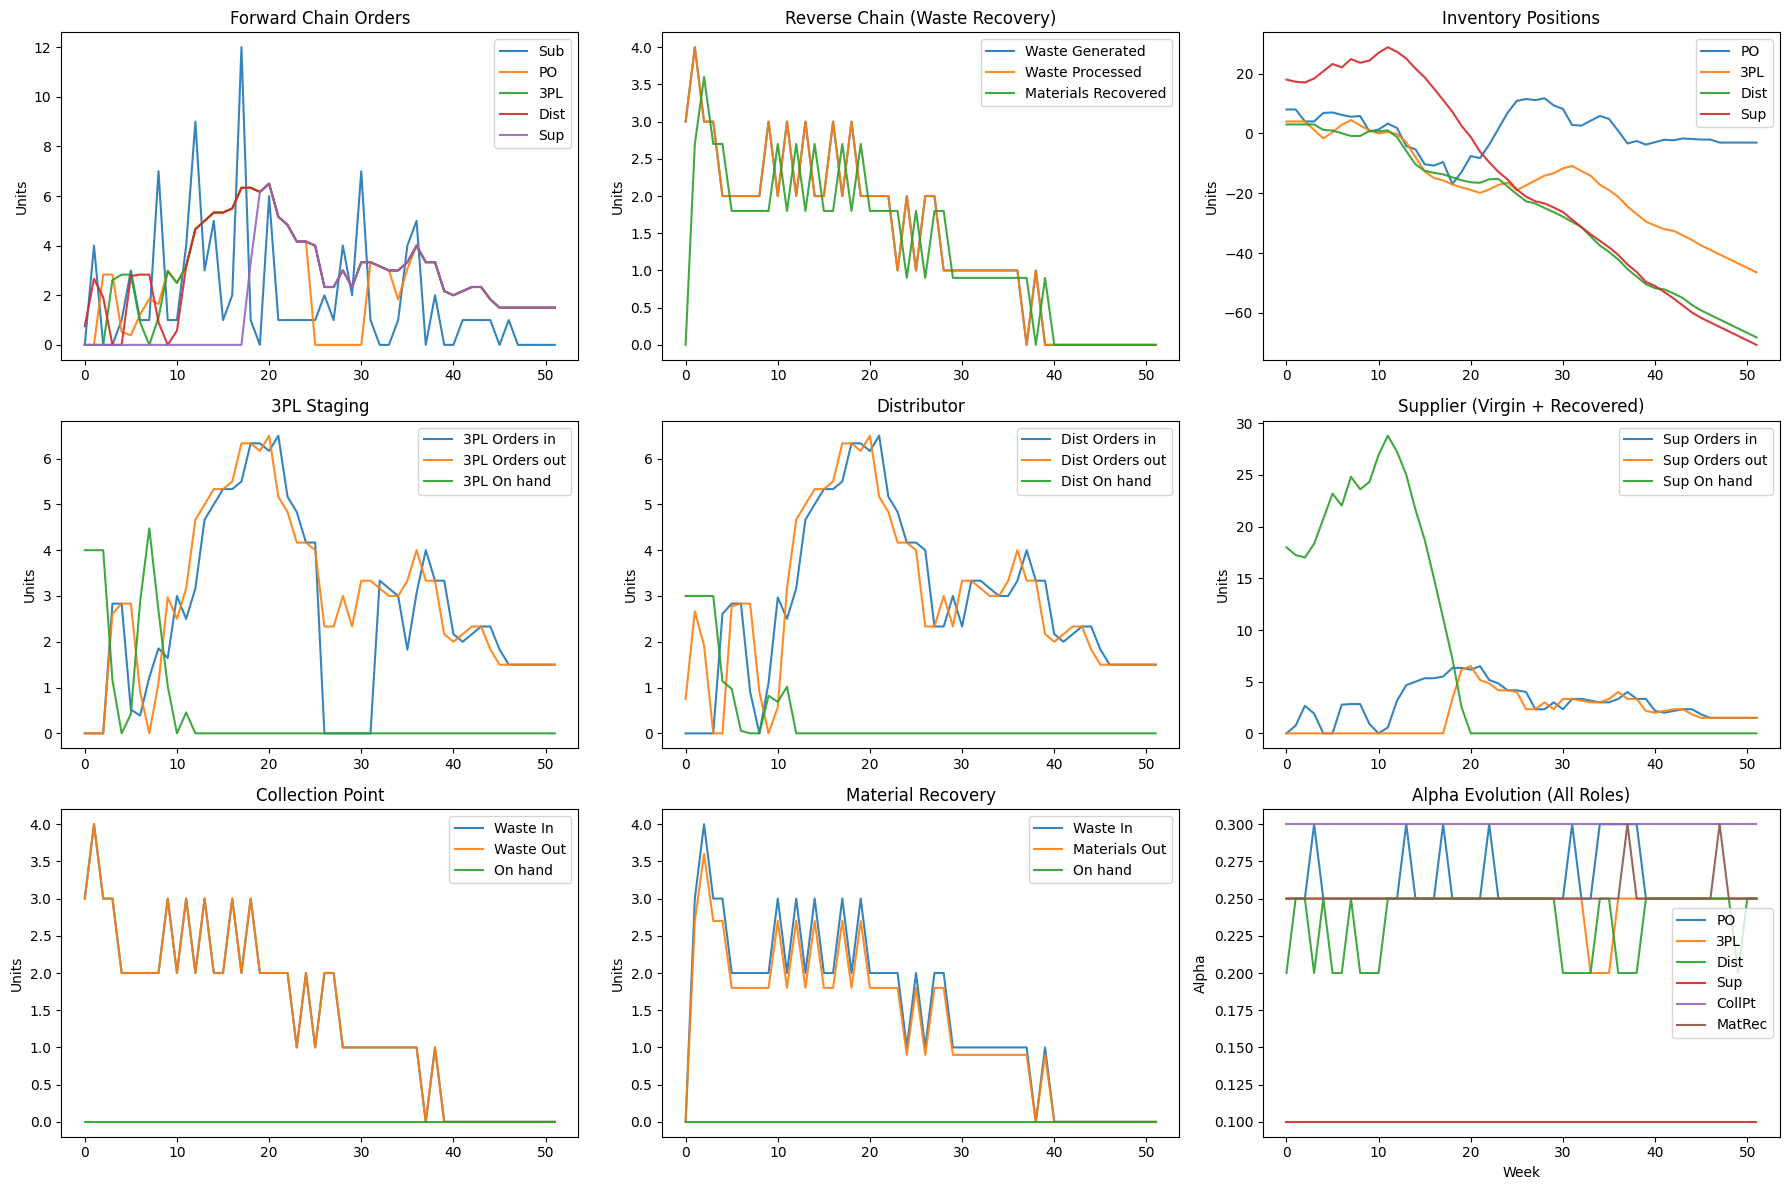


BULLWHIP ANALYSIS:
Customer demand variance (baseline): 6.79

Bullwhip ratios (Order variance / Customer variance):
Sub    : 1.00
PO     : 0.55
3PL    : 0.34
Dist   : 0.37
Sup    : 0.40

Waste generation variance: 0.98
Waste processing ratios (Order variance / Waste variance):
CollPt : 1.00
MatRec : 0.85


In [6]:
# ===== Post-Run Diagnostics (CLOSED LOOP) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _roles_by_prefix(prefixes):
    return [r for r in ROLES if any(r == p or r.startswith(p) for p in prefixes)]

# Extended groupings for closed-loop supply chain
SUBS      = _roles_by_prefix(["Sub"])
POS_      = _roles_by_prefix(["PO"])
THREEPLS  = _roles_by_prefix(["3PL"])
DISTS_    = _roles_by_prefix(["Dist"])
SUPS_     = _roles_by_prefix(["Sup"])
COLLPTS_  = _roles_by_prefix(["CollPoint"])  # New: Collection Points
MATRECOVS = _roles_by_prefix(["MatRecov"])   # New: Material Recovery

def _sum_series(role_list, series_dict):
    if not role_list:
        return None
    arrs = [np.asarray(series_dict[r], dtype=float) for r in role_list]
    return np.sum(arrs, axis=0)

def _avg_coeff(role_list, coeff_logs, key):
    vals = []
    for r in role_list:
        if r in coeff_logs and coeff_logs[r]:
            vals.extend([float(c[key]) for c in coeff_logs[r] if key in c])
    return (np.mean(vals) if vals else np.nan)

def _count_true(role_list, coeff_logs, key):
    cnt = 0
    for r in role_list:
        if r in coeff_logs and coeff_logs[r]:
            cnt += sum(bool(c.get(key, False)) for c in coeff_logs[r])
    return cnt

if 'hist_roles' in globals() and 'coeff_logs' in globals():
    T = len(next(iter(hist_roles["on_hand"].values())))
    weeks_to_check = [w for w in [0, 10, 20, 30, 40, 50] if w < T]

    # ---------- ORDER ACTIVITY (category totals) ----------
    print("ORDER ACTIVITY (category totals):")
    cat_map = {
        "Sub":     SUBS,
        "PO":      POS_,
        "3PL":     THREEPLS,
        "Dist":    DISTS_,
        "Sup":     SUPS_,
        "CollPt":  COLLPTS_,   # Collection Points
        "MatRec":  MATRECOVS,  # Material Recovery
    }
    for cat, roles in cat_map.items():
        series = _sum_series(roles, hist_roles["orders_out"])
        if series is None:
            continue
        total_orders = series.sum()
        non_zero_weeks = int((series > 0.1).sum())
        max_order = float(series.max())
        print(f"{cat:7s}: Total={total_orders:7.1f}, Active_weeks={non_zero_weeks:2d}/{T}, Max={max_order:7.1f}")

    # ---------- CLOSED-LOOP FLOW ANALYSIS ----------
    print("\nCLOSED-LOOP FLOW ANALYSIS:")
    # Waste generation and recovery metrics
    if "waste_in" in hist_roles and SUBS:
        total_waste_generated = float(_sum_series(SUBS, hist_roles["waste_in"]).sum())
        print(f"Total waste generated by contractors: {total_waste_generated:.1f} units")

        if COLLPTS_:
            waste_collected = float(_sum_series(COLLPTS_, hist_roles["orders_in"]).sum())
            collection_rate = (waste_collected / total_waste_generated * 100) if total_waste_generated > 0 else 0
            print(f"Total waste collected: {waste_collected:.1f} units ({collection_rate:.1f}% of generated)")

        if MATRECOVS:
            materials_recovered = float(_sum_series(MATRECOVS, hist_roles["orders_out"]).sum())
            recovery_rate = (materials_recovered / waste_collected * 100) if waste_collected > 0 else 0
            print(f"Total materials recovered: {materials_recovered:.1f} units ({recovery_rate:.1f}% of collected)")

            # How much did recovered materials contribute to supplier inventory?
            if SUPS_:
                total_sup_orders = float(_sum_series(SUPS_, hist_roles["orders_in"]).sum())
                recovery_contribution = (materials_recovered / total_sup_orders * 100) if total_sup_orders > 0 else 0
                print(f"Recovery contribution to supplier: {recovery_contribution:.1f}% of supplier input")

    # ---------- WEEKLY ORDER PATTERNS (category totals) ----------
    print("\nWEEKLY ORDER PATTERNS (category totals):")
    order_rows = []
    for t in weeks_to_check:
        row = {"week": t}
        for cat, roles in cat_map.items():
            s = _sum_series(roles, hist_roles["orders_out"])
            if s is not None:
                row[f"{cat}_order"] = float(s[t])
        order_rows.append(row)
    df_orders = pd.DataFrame(order_rows)
    with pd.option_context('display.float_format', lambda x: f"{x:7.1f}"):
        print(df_orders.to_string(index=False))

    # ---------- INVENTORY ANALYSIS (all categories) ----------
    print("\nINVENTORY ANALYSIS (category totals):")
    for cat, roles in [("3PL", THREEPLS), ("Dist", DISTS_), ("Sup", SUPS_), ("CollPt", COLLPTS_), ("MatRec", MATRECOVS)]:
        on_hand  = _sum_series(roles, hist_roles["on_hand"])
        backlog  = _sum_series(roles, hist_roles["backlog"])
        pipeline = _sum_series(roles, hist_roles["pipeline"])
        if on_hand is None:
            continue
        inv_pos = on_hand + pipeline - backlog
        wk = weeks_to_check[2] if len(weeks_to_check) >= 3 else weeks_to_check[-1]
        print(f"\n{cat}:")
        print(f"  Week {wk:2d}: on_hand={on_hand[wk]:.1f}, backlog={backlog[wk]:.1f}, pipeline={pipeline[wk]:.1f}")
        print(f"  Week {wk:2d}: inv_pos={inv_pos[wk]:.1f}")
        start = min(10, T-1)
        print(f"  Avg inventory (weeks {start}-{T-1}): {on_hand[start:].mean():.1f}")

    # ---------- COEFFICIENT ANALYSIS (averaged by category) ----------
    print("\nCOEFFICIENT ANALYSIS (category averages):")
    for cat, roles in cat_map.items():
        a = _avg_coeff(roles, coeff_logs, "alpha")
        s = _avg_coeff(roles, coeff_logs, "service_level")
        l = _avg_coeff(roles, coeff_logs, "lot_multiplier")
        e = _count_true(roles, coeff_logs, "expedite")
        if not np.isnan(a):
            print(f"{cat:7s}: alpha={a:.2f}, service={s:.2f}, lot={l:.2f}, expedites={e}")

    # ---------- SUPPLY CHAIN FLOW (category totals) ----------
    print("\nSUPPLY CHAIN FLOW (category totals):")
    flow_rows = []
    for t in [w for w in [10, 20, 30, 40] if w < T]:
        row = {"week": t}
        # Forward chain flows
        row["Sub_out"] = float(_sum_series(SUBS, hist_roles["orders_out"])[t]) if SUBS else 0.0
        row["PO_in"]  = float(_sum_series(POS_, hist_roles["orders_in"])[t])  if POS_ else 0.0
        row["PO_out"] = float(_sum_series(POS_, hist_roles["orders_out"])[t]) if POS_ else 0.0
        row["3PL_in"]  = float(_sum_series(THREEPLS, hist_roles["orders_in"])[t])  if THREEPLS else 0.0
        row["3PL_out"] = float(_sum_series(THREEPLS, hist_roles["orders_out"])[t]) if THREEPLS else 0.0
        row["Dist_in"]  = float(_sum_series(DISTS_, hist_roles["orders_in"])[t])  if DISTS_ else 0.0
        row["Dist_out"] = float(_sum_series(DISTS_, hist_roles["orders_out"])[t]) if DISTS_ else 0.0
        row["Sup_in"] = float(_sum_series(SUPS_, hist_roles["orders_in"])[t]) if SUPS_ else 0.0
        # Reverse chain flows (waste)
        if "waste_in" in hist_roles and SUBS:
            row["Waste_gen"] = float(_sum_series(SUBS, hist_roles["waste_in"])[t])
        row["Coll_out"] = float(_sum_series(COLLPTS_, hist_roles["orders_out"])[t]) if COLLPTS_ else 0.0
        row["Rec_out"] = float(_sum_series(MATRECOVS, hist_roles["orders_out"])[t]) if MATRECOVS else 0.0
        flow_rows.append(row)
    df_flow = pd.DataFrame(flow_rows)
    with pd.option_context('display.float_format', lambda x: f"{x:7.1f}"):
        print(df_flow.to_string(index=False))

    # ---------- PLOTS (category totals) ----------
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))

    # Plot 1: Orders Out by Category (Forward Chain)
    ax = axes[0,0]
    for cat, roles in [("Sub", SUBS), ("PO", POS_), ("3PL", THREEPLS), ("Dist", DISTS_), ("Sup", SUPS_)]:
        s = _sum_series(roles, hist_roles["orders_out"])
        if s is not None:
            ax.plot(s, label=cat, alpha=0.9)
    ax.set_title("Forward Chain Orders"); ax.legend(); ax.set_ylabel("Units")

    # Plot 2: Reverse Chain Flow
    ax = axes[0,1]
    if "waste_in" in hist_roles and SUBS:
        ax.plot(_sum_series(SUBS, hist_roles["waste_in"]), label="Waste Generated", alpha=0.9)
    if COLLPTS_:
        ax.plot(_sum_series(COLLPTS_, hist_roles["orders_out"]), label="Waste Processed", alpha=0.9)
    if MATRECOVS:
        ax.plot(_sum_series(MATRECOVS, hist_roles["orders_out"]), label="Materials Recovered", alpha=0.9)
    ax.set_title("Reverse Chain (Waste Recovery)"); ax.legend(); ax.set_ylabel("Units")

    # Plot 3: Inventory Positions
    ax = axes[0,2]
    for cat, roles in [("PO", POS_), ("3PL", THREEPLS), ("Dist", DISTS_), ("Sup", SUPS_)]:
        oh = _sum_series(roles, hist_roles["on_hand"])
        bl = _sum_series(roles, hist_roles["backlog"])
        pl = _sum_series(roles, hist_roles["pipeline"])
        if oh is None:
            continue
        inv_pos = oh + pl - bl
        ax.plot(inv_pos, label=cat, alpha=0.9)
    ax.set_title("Inventory Positions"); ax.legend(); ax.set_ylabel("Units")

    # Plot 4: 3PL Staging
    ax = axes[1,0]
    if THREEPLS:
        ax.plot(_sum_series(THREEPLS, hist_roles["orders_in"]),  label="3PL Orders in",  alpha=0.9)
        ax.plot(_sum_series(THREEPLS, hist_roles["orders_out"]), label="3PL Orders out", alpha=0.9)
        ax.plot(_sum_series(THREEPLS, hist_roles["on_hand"]),    label="3PL On hand",    alpha=0.9)
    ax.set_title("3PL Staging"); ax.legend(); ax.set_ylabel("Units")

    # Plot 5: Distributor
    ax = axes[1,1]
    if DISTS_:
        ax.plot(_sum_series(DISTS_, hist_roles["orders_in"]),  label="Dist Orders in",  alpha=0.9)
        ax.plot(_sum_series(DISTS_, hist_roles["orders_out"]), label="Dist Orders out", alpha=0.9)
        ax.plot(_sum_series(DISTS_, hist_roles["on_hand"]),    label="Dist On hand",    alpha=0.9)
    ax.set_title("Distributor"); ax.legend(); ax.set_ylabel("Units")

    # Plot 6: Supplier (now shows both virgin and recovered materials)
    ax = axes[1,2]
    if SUPS_:
        ax.plot(_sum_series(SUPS_, hist_roles["orders_in"]),  label="Sup Orders in",  alpha=0.9)
        ax.plot(_sum_series(SUPS_, hist_roles["orders_out"]), label="Sup Orders out", alpha=0.9)
        ax.plot(_sum_series(SUPS_, hist_roles["on_hand"]),    label="Sup On hand",    alpha=0.9)
    ax.set_title("Supplier (Virgin + Recovered)"); ax.legend(); ax.set_ylabel("Units")

    # Plot 7: Collection Point
    ax = axes[2,0]
    if COLLPTS_:
        ax.plot(_sum_series(COLLPTS_, hist_roles["orders_in"]),  label="Waste In",  alpha=0.9)
        ax.plot(_sum_series(COLLPTS_, hist_roles["orders_out"]), label="Waste Out", alpha=0.9)
        ax.plot(_sum_series(COLLPTS_, hist_roles["on_hand"]),    label="On hand",    alpha=0.9)
    ax.set_title("Collection Point"); ax.legend(); ax.set_ylabel("Units")

    # Plot 8: Material Recovery
    ax = axes[2,1]
    if MATRECOVS:
        ax.plot(_sum_series(MATRECOVS, hist_roles["orders_in"]),  label="Waste In",  alpha=0.9)
        ax.plot(_sum_series(MATRECOVS, hist_roles["orders_out"]), label="Materials Out", alpha=0.9)
        ax.plot(_sum_series(MATRECOVS, hist_roles["on_hand"]),    label="On hand",    alpha=0.9)
    ax.set_title("Material Recovery"); ax.legend(); ax.set_ylabel("Units")

    # Plot 9: Alpha Evolution
    ax = axes[2,2]
    for cat, roles in [("PO", POS_), ("3PL", THREEPLS), ("Dist", DISTS_), ("Sup", SUPS_), ("CollPt", COLLPTS_), ("MatRec", MATRECOVS)]:
        alphas_per_role = []
        for r in roles:
            if r in coeff_logs and coeff_logs[r]:
                alphas_per_role.append([c["alpha"] for c in coeff_logs[r]])
        if not alphas_per_role:
            continue
        min_len = min(len(a) for a in alphas_per_role)
        if min_len == 0:
            continue
        arr = np.array([a[:min_len] for a in alphas_per_role], dtype=float)
        ax.plot(arr.mean(axis=0), label=cat, alpha=0.9)
    ax.set_title("Alpha Evolution (All Roles)"); ax.legend(); ax.set_ylabel("Alpha"); ax.set_xlabel("Week")

    plt.tight_layout()
    plt.show()

    # ---------- BULLWHIP ANALYSIS ----------
    print("\nBULLWHIP ANALYSIS:")
    demand_vars = {}
    order_vars = {}

    for cat, roles in cat_map.items():
        orders = _sum_series(roles, hist_roles["orders_out"])
        if orders is not None and len(orders) > 10:
            # Calculate variance from week 10 onwards (after initial stabilization)
            order_vars[cat] = float(np.var(orders[10:]))

    # Customer demand variance as baseline
    if len(customerDemand) > 10:
        customer_var = float(np.var(customerDemand[10:]))
        print(f"Customer demand variance (baseline): {customer_var:.2f}")

        print("\nBullwhip ratios (Order variance / Customer variance):")
        for cat in ["Sub", "PO", "3PL", "Dist", "Sup"]:
            if cat in order_vars:
                bullwhip = order_vars[cat] / customer_var if customer_var > 0 else float('inf')
                print(f"{cat:7s}: {bullwhip:.2f}")

        # Reverse chain doesn't follow customer demand, so separate analysis
        if len(projectWaste) > 10:
            waste_var = float(np.var(projectWaste[10:]))
            print(f"\nWaste generation variance: {waste_var:.2f}")
            print("Waste processing ratios (Order variance / Waste variance):")
            for cat in ["CollPt", "MatRec"]:
                if cat in order_vars:
                    waste_ratio = order_vars[cat] / waste_var if waste_var > 0 else float('inf')
                    print(f"{cat:7s}: {waste_ratio:.2f}")

else:
    print("Run the simulation first to generate hist_roles and coeff_logs data.")

=== FORWARD CHAIN BULLWHIP ANALYSIS ===
Bullwhip metrics vs customer demand (post burn-in = 10):
role  bullwhip_ratio_var  amplification_std  mean_ratio
 3PL               0.342              0.585       1.715
Dist               0.367              0.606       1.692
  PO               0.549              0.741       1.489
 Sub               1.000              1.000       1.000
 Sup               0.404              0.636       1.223

=== REVERSE CHAIN PROCESSING ANALYSIS ===
Processing metrics vs waste generation (post burn-in = 10):
     role  processing_ratio_var  processing_std  processing_mean_ratio
CollPoint                 1.000           1.000                  1.000
 MatRecov                 0.848           0.921                  0.956

=== CLOSED-LOOP EFFICIENCY METRICS ===
Waste generated (post burn-in): 48.0 units
Waste collected: 48.0 units (100.0%)
Materials recovered: 45.9 units (95.6% of collected)
Overall recovery efficiency: 95.6% of generated waste
Supplier recovery depend

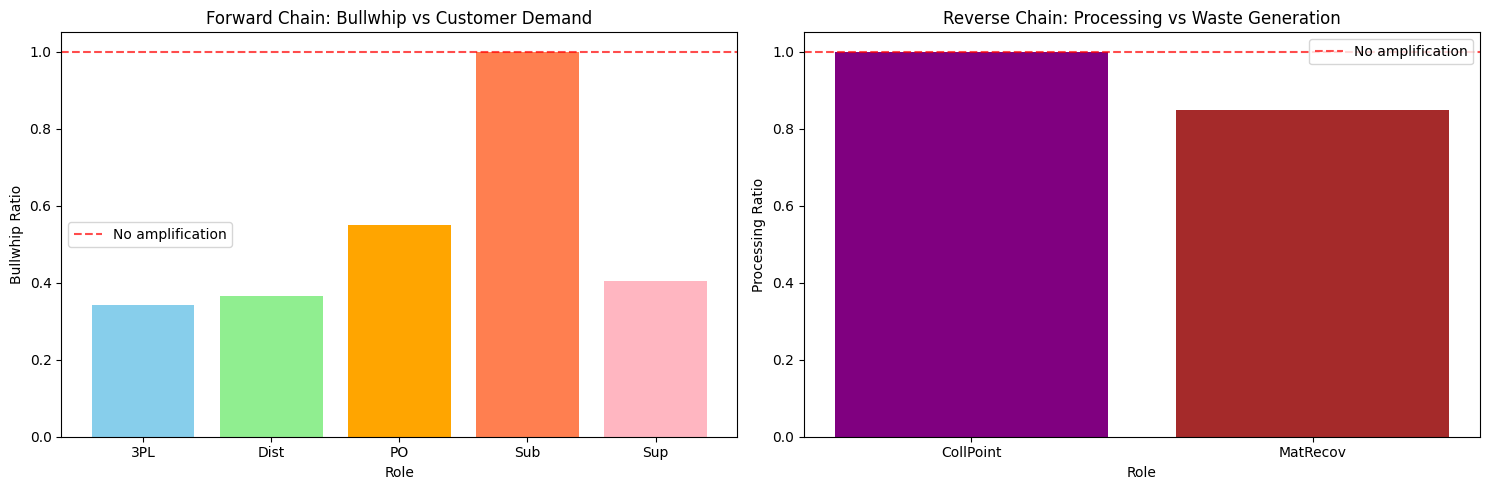

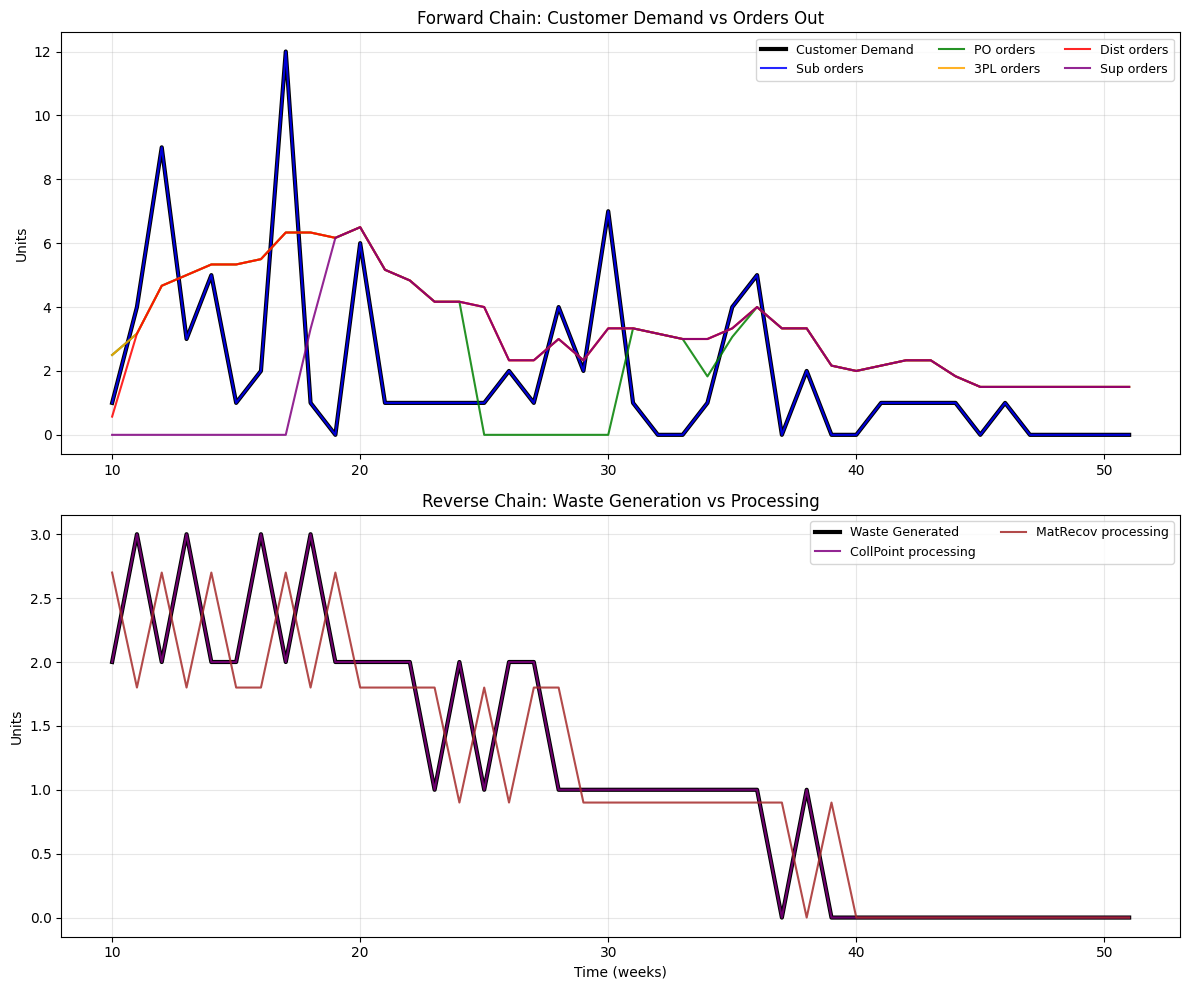

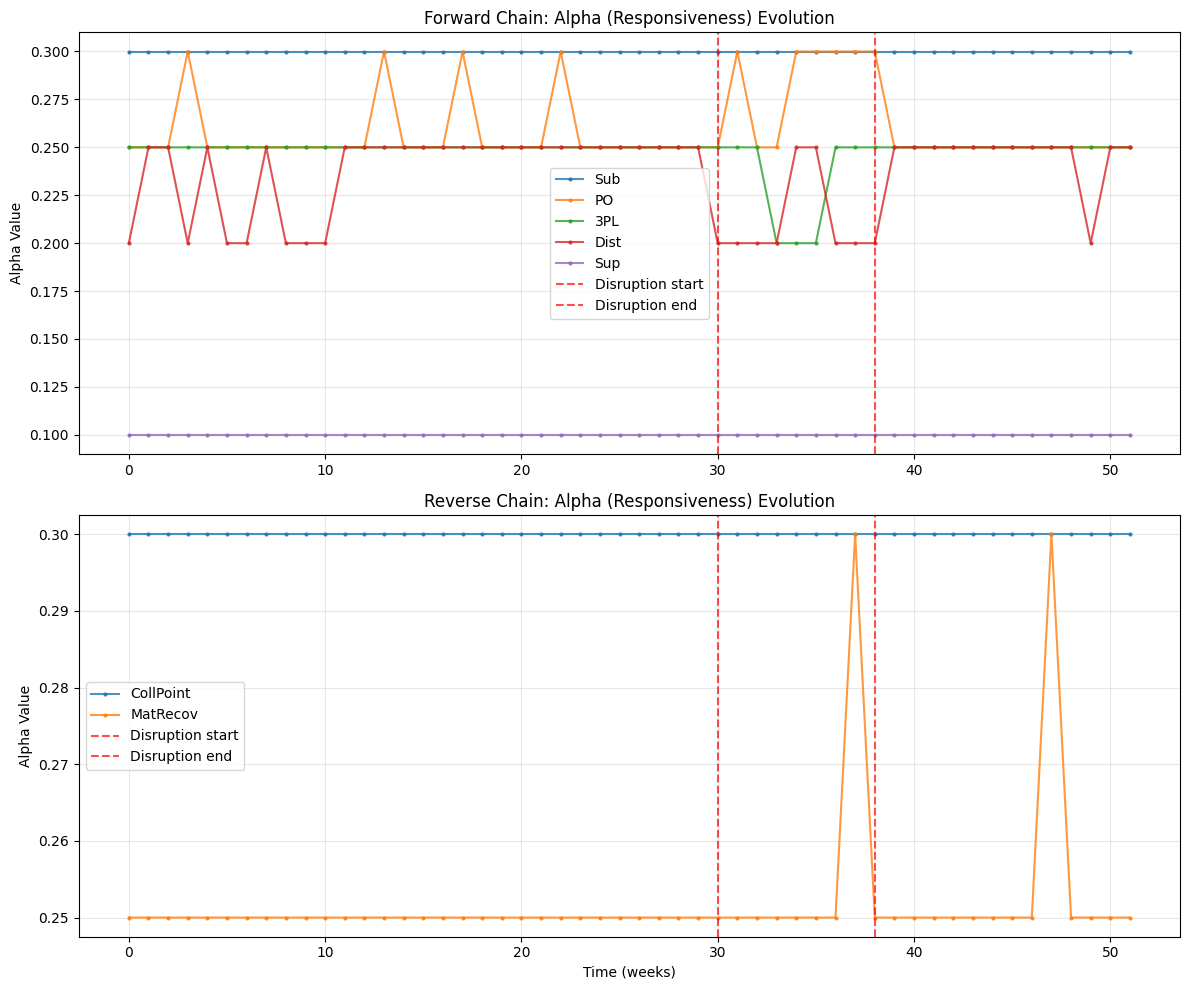

In [7]:
# ===== R5 — KPIs + coefficient & sharing summaries (CLOSED LOOP) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define burn-in period to exclude initial startup effects
burnIn = 10  # exclude first 10 weeks from analysis

# Split roles into forward and reverse chain for analysis
forward_roles = [r for r in ["Sub", "PO", "3PL", "Dist", "Sup"] if r in ROLES]
reverse_roles = [r for r in ["CollPoint", "MatRecov"] if r in ROLES]
all_roles = forward_roles + reverse_roles

def compute_metrics_roles(hist, demand, roles, burnIn=0):
    rows = []
    cust = np.asarray(demand[burnIn:], dtype=float)
    var_cust = float(np.var(cust, ddof=0))
    std_cust = float(np.std(cust, ddof=0))
    mean_cust = float(np.mean(cust))

    for r in roles:
        orders = np.asarray(hist["orders_out"][r][burnIn:], dtype=float)
        var_orders = float(np.var(orders, ddof=0))
        std_orders = float(np.std(orders, ddof=0))
        mean_orders = float(np.mean(orders))

        rows.append({
            "role": r,
            "bullwhip_ratio_var": (var_orders / var_cust) if var_cust > 0 else np.nan,
            "amplification_std": (std_orders / std_cust) if std_cust > 0 else np.nan,
            "mean_ratio": (mean_orders / mean_cust) if mean_cust > 0 else np.nan,
        })
    return pd.DataFrame(rows).sort_values("role")

def compute_waste_metrics(hist, waste_demand, roles, burnIn=0):
    """Compute bullwhip metrics for waste processing roles using waste demand as baseline"""
    rows = []
    waste = np.asarray(waste_demand[burnIn:], dtype=float)
    var_waste = float(np.var(waste, ddof=0))
    std_waste = float(np.std(waste, ddof=0))
    mean_waste = float(np.mean(waste))

    for r in roles:
        orders = np.asarray(hist["orders_out"][r][burnIn:], dtype=float)
        var_orders = float(np.var(orders, ddof=0))
        std_orders = float(np.std(orders, ddof=0))
        mean_orders = float(np.mean(orders))

        rows.append({
            "role": r,
            "processing_ratio_var": (var_orders / var_waste) if var_waste > 0 else np.nan,
            "processing_std": (std_orders / std_waste) if std_waste > 0 else np.nan,
            "processing_mean_ratio": (mean_orders / mean_waste) if mean_waste > 0 else np.nan,
        })
    return pd.DataFrame(rows).sort_values("role")

# ---- FORWARD CHAIN BULLWHIP ANALYSIS
print("=== FORWARD CHAIN BULLWHIP ANALYSIS ===")
df_kpi_forward = compute_metrics_roles(hist_roles, customerDemand, forward_roles, burnIn=burnIn)
print(f"Bullwhip metrics vs customer demand (post burn-in = {burnIn}):")
print(df_kpi_forward.to_string(index=False, float_format=lambda x: f"{x:0.3f}"))

# ---- REVERSE CHAIN PROCESSING ANALYSIS
print("\n=== REVERSE CHAIN PROCESSING ANALYSIS ===")
df_kpi_reverse = compute_waste_metrics(hist_roles, projectWaste, reverse_roles, burnIn=burnIn)
print(f"Processing metrics vs waste generation (post burn-in = {burnIn}):")
print(df_kpi_reverse.to_string(index=False, float_format=lambda x: f"{x:0.3f}"))

# ---- CLOSED-LOOP EFFICIENCY METRICS
print("\n=== CLOSED-LOOP EFFICIENCY METRICS ===")
if "waste_in" in hist_roles:
    # Overall waste flow efficiency
    total_waste_gen = np.sum(hist_roles["waste_in"]["Sub"][burnIn:]) if "Sub" in hist_roles["waste_in"] else 0
    total_collected = np.sum(hist_roles["orders_out"]["CollPoint"][burnIn:]) if "CollPoint" in hist_roles["orders_out"] else 0
    total_recovered = np.sum(hist_roles["orders_out"]["MatRecov"][burnIn:]) if "MatRecov" in hist_roles["orders_out"] else 0

    collection_efficiency = (total_collected / total_waste_gen * 100) if total_waste_gen > 0 else 0
    recovery_efficiency = (total_recovered / total_collected * 100) if total_collected > 0 else 0
    overall_efficiency = (total_recovered / total_waste_gen * 100) if total_waste_gen > 0 else 0

    print(f"Waste generated (post burn-in): {total_waste_gen:.1f} units")
    print(f"Waste collected: {total_collected:.1f} units ({collection_efficiency:.1f}%)")
    print(f"Materials recovered: {total_recovered:.1f} units ({recovery_efficiency:.1f}% of collected)")
    print(f"Overall recovery efficiency: {overall_efficiency:.1f}% of generated waste")

    # Supplier dependency on recovered materials
    if "Sup" in hist_roles["orders_in"]:
        sup_orders = np.sum(hist_roles["orders_in"]["Sup"][burnIn:])
        recovery_share = (total_recovered / sup_orders * 100) if sup_orders > 0 else 0
        print(f"Supplier recovery dependency: {recovery_share:.1f}% of supplier input from recovery")

# ---- Coefficient logs → DataFrame
rows = []
for r, logs in coeff_logs.items():
    for rec in logs:
        rows.append({"role": r, **{k: rec.get(k) for k in ("t","alpha","service_level","lot_multiplier","expedite")}})
coeff_df = pd.DataFrame(rows).sort_values(["role","t"])
print("\nSample of coefficient choices (all 7 roles):")
print(coeff_df.head(14).to_string(index=False))  # Show samples for 7 roles

# Distributions by role
alpha_dist = coeff_df.groupby(["role","alpha"]).size().rename("count").reset_index()
sl_dist    = coeff_df.groupby(["role","service_level"]).size().rename("count").reset_index()
lot_dist   = coeff_df.groupby(["role","lot_multiplier"]).size().rename("count").reset_index()
exp_dist   = coeff_df.groupby(["role","expedite"]).size().rename("count").reset_index()

print("\nAlpha choices (counts):")
print(alpha_dist.pivot(index="role", columns="alpha", values="count").fillna(0).astype(int))
print("\nService level choices (counts):")
print(sl_dist.pivot(index="role", columns="service_level", values="count").fillna(0).astype(int))
print("\nLot multiplier choices (counts):")
print(lot_dist.pivot(index="role", columns="lot_multiplier", values="count").fillna(0).astype(int))
print("\nExpedite choices (counts):")
print(exp_dist.pivot(index="role", columns="expedite", values="count").fillna(0).astype(int))

# ---- Sharing policy changes summary
policy_rows = []
for r, logs in coeff_logs.items():
    add_total = sum(len(rec.get("share_add", [])) for rec in logs)
    drop_total = sum(len(rec.get("share_drop", [])) for rec in logs)
    policy_rows.append({"role": r, "share_add_total": add_total, "share_drop_total": drop_total})
df_policy = pd.DataFrame(policy_rows).sort_values("role")
print("\nSharing policy changes (totals over run):")
print(df_policy.to_string(index=False))

# Current published keys by role (from InfoBank policies)
current_share = {r: profiles[r].share_keys for r in ROLES}
print("\nCurrent share policy keys by role:")
for r in ROLES:
    print(f"  {r}: {current_share[r]}")

# ---- Enhanced Analysis for 7-role closed-loop chain
print("\n=== 7-ECHELON CLOSED-LOOP CHAIN ANALYSIS ===")

# Role-specific coefficient averages
print("\nAverage coefficients by role:")
role_avg_coeffs = coeff_df.groupby("role")[["alpha", "service_level", "lot_multiplier"]].mean()
print(role_avg_coeffs.round(3))

# Expedite frequency by role
print("\nExpedite frequency by role:")
expedite_freq = coeff_df.groupby("role")["expedite"].mean()
print(expedite_freq.round(3))

# Pre-crisis vs Crisis vs Post-crisis comparison
periods = {
    "pre_crisis": (0, 30),
    "crisis": (30, 38),
    "post_crisis": (38, 52)
}

print("\nPeriod-based coefficient analysis:")
for period_name, (start, end) in periods.items():
    period_data = coeff_df[(coeff_df["t"] >= start) & (coeff_df["t"] < end)]
    if len(period_data) > 0:
        print(f"\n{period_name.upper()}:")
        period_avg = period_data.groupby("role")[["alpha", "service_level", "lot_multiplier"]].mean()
        print(period_avg.round(3))

# Compare forward vs reverse chain behavior
print("\nForward vs Reverse Chain Coefficient Comparison:")
forward_coeffs = coeff_df[coeff_df["role"].isin(forward_roles)][["alpha", "service_level", "lot_multiplier"]].mean()
reverse_coeffs = coeff_df[coeff_df["role"].isin(reverse_roles)][["alpha", "service_level", "lot_multiplier"]].mean()
print("Forward chain averages:")
print(forward_coeffs.round(3))
print("Reverse chain averages:")
print(reverse_coeffs.round(3))

# ---- Plots
# 1) Bullwhip ratio comparison: Forward vs Reverse chains
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Forward chain bullwhip
ax1.bar(df_kpi_forward["role"], df_kpi_forward["bullwhip_ratio_var"],
        color=['skyblue', 'lightgreen', 'orange', 'coral', 'lightpink'])
ax1.axhline(1.0, linestyle="--", color='red', alpha=0.7, label='No amplification')
ax1.set_title("Forward Chain: Bullwhip vs Customer Demand")
ax1.set_ylabel("Bullwhip Ratio")
ax1.set_xlabel("Role")
ax1.legend()

# Reverse chain processing ratios
if len(df_kpi_reverse) > 0:
    ax2.bar(df_kpi_reverse["role"], df_kpi_reverse["processing_ratio_var"],
            color=['purple', 'brown'])
    ax2.axhline(1.0, linestyle="--", color='red', alpha=0.7, label='No amplification')
    ax2.set_title("Reverse Chain: Processing vs Waste Generation")
    ax2.set_ylabel("Processing Ratio")
    ax2.set_xlabel("Role")
    ax2.legend()

plt.tight_layout()
plt.show()

# 2) Orders_out comparison: Customer demand vs Forward chain + Waste vs Reverse chain
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Forward chain vs customer demand
t_idx = np.arange(len(customerDemand))
ax1.plot(t_idx[burnIn:], customerDemand[burnIn:], label="Customer Demand", linewidth=3, color='black')
colors = ['blue', 'green', 'orange', 'red', 'purple']
for i, r in enumerate(forward_roles):
    ax1.plot(t_idx[burnIn:], hist_roles["orders_out"][r][burnIn:],
             label=f"{r} orders", alpha=0.85, color=colors[i])
ax1.set_title("Forward Chain: Customer Demand vs Orders Out")
ax1.set_ylabel("Units")
ax1.legend(ncol=3, fontsize=9)
ax1.grid(True, alpha=0.3)

# Reverse chain vs waste generation
ax2.plot(t_idx[burnIn:], projectWaste[burnIn:], label="Waste Generated", linewidth=3, color='black')
colors_reverse = ['purple', 'brown']
for i, r in enumerate(reverse_roles):
    ax2.plot(t_idx[burnIn:], hist_roles["orders_out"][r][burnIn:],
             label=f"{r} processing", alpha=0.85, color=colors_reverse[i])
ax2.set_title("Reverse Chain: Waste Generation vs Processing")
ax2.set_xlabel("Time (weeks)")
ax2.set_ylabel("Units")
ax2.legend(ncol=2, fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3) Alpha evolution by chain
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Forward chain alpha evolution
for r in forward_roles:
    if r in coeff_logs:
        times = [rec["t"] for rec in coeff_logs[r]]
        alphas = [rec["alpha"] for rec in coeff_logs[r]]
        ax1.plot(times, alphas, label=f"{r}", marker='o', markersize=2, alpha=0.8)

ax1.axvline(x=30, color='red', linestyle='--', alpha=0.7, label='Disruption start')
ax1.axvline(x=38, color='red', linestyle='--', alpha=0.7, label='Disruption end')
ax1.set_title("Forward Chain: Alpha (Responsiveness) Evolution")
ax1.set_ylabel("Alpha Value")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Reverse chain alpha evolution
for r in reverse_roles:
    if r in coeff_logs:
        times = [rec["t"] for rec in coeff_logs[r]]
        alphas = [rec["alpha"] for rec in coeff_logs[r]]
        ax2.plot(times, alphas, label=f"{r}", marker='o', markersize=2, alpha=0.8)

ax2.axvline(x=30, color='red', linestyle='--', alpha=0.7, label='Disruption start')
ax2.axvline(x=38, color='red', linestyle='--', alpha=0.7, label='Disruption end')
ax2.set_title("Reverse Chain: Alpha (Responsiveness) Evolution")
ax2.set_xlabel("Time (weeks)")
ax2.set_ylabel("Alpha Value")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Optional: save summaries
# coeff_df.to_csv("coeff_choices_closed_loop.csv", index=False)
# df_kpi_forward.to_csv("kpi_bullwhip_forward.csv", index=False)
# df_kpi_reverse.to_csv("kpi_processing_reverse.csv", index=False)
# df_policy.to_csv("sharing_changes_closed_loop.csv", index=False)

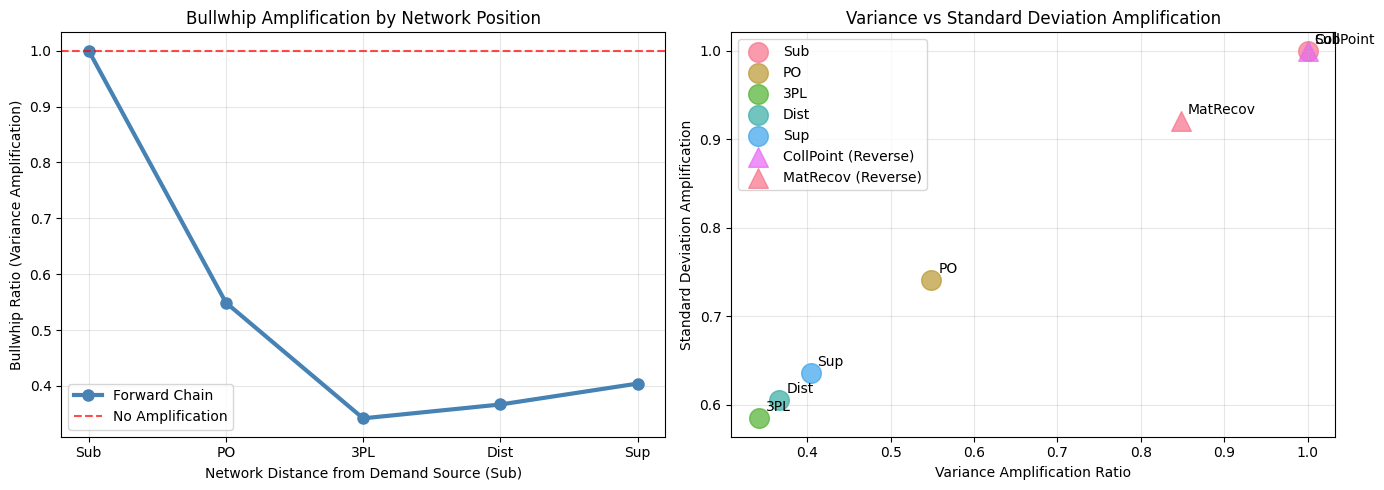

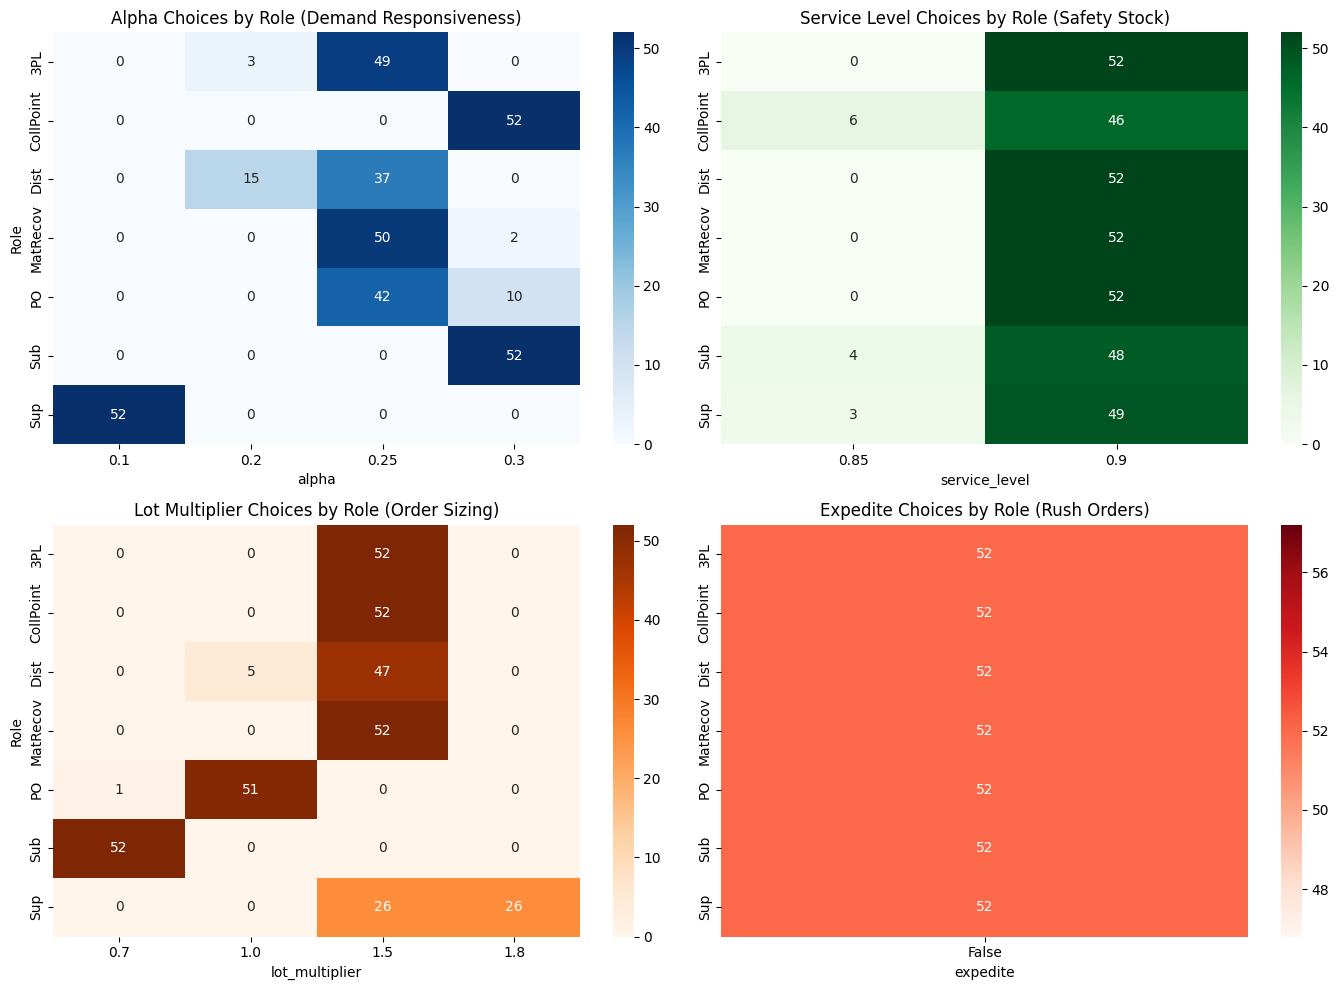

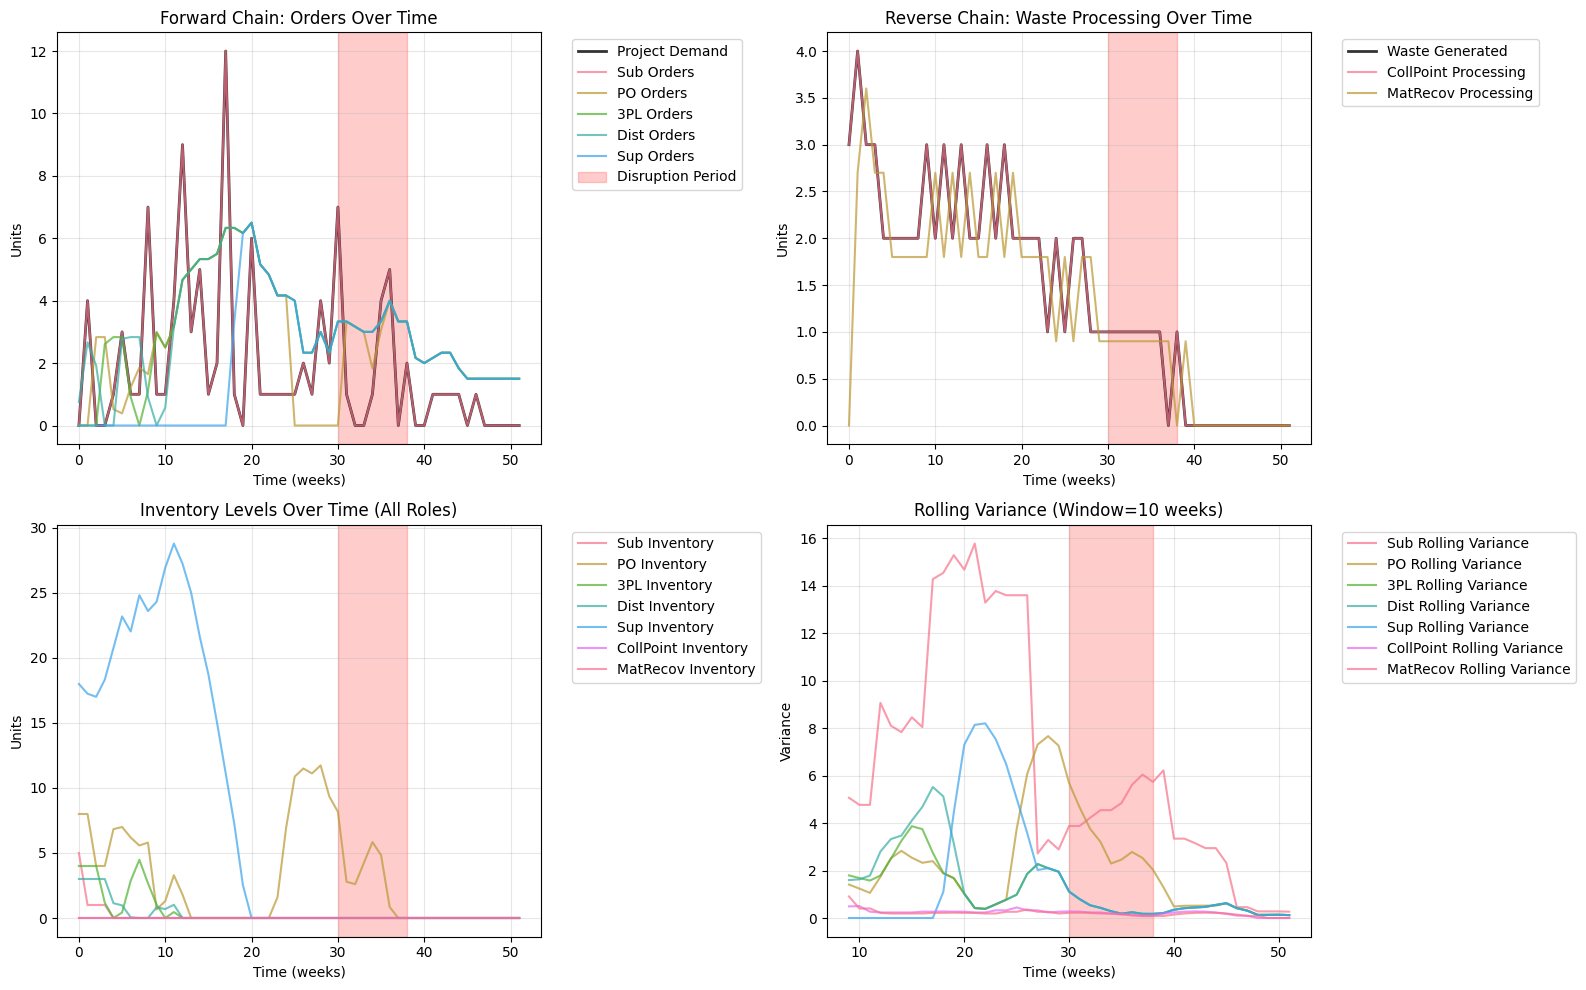

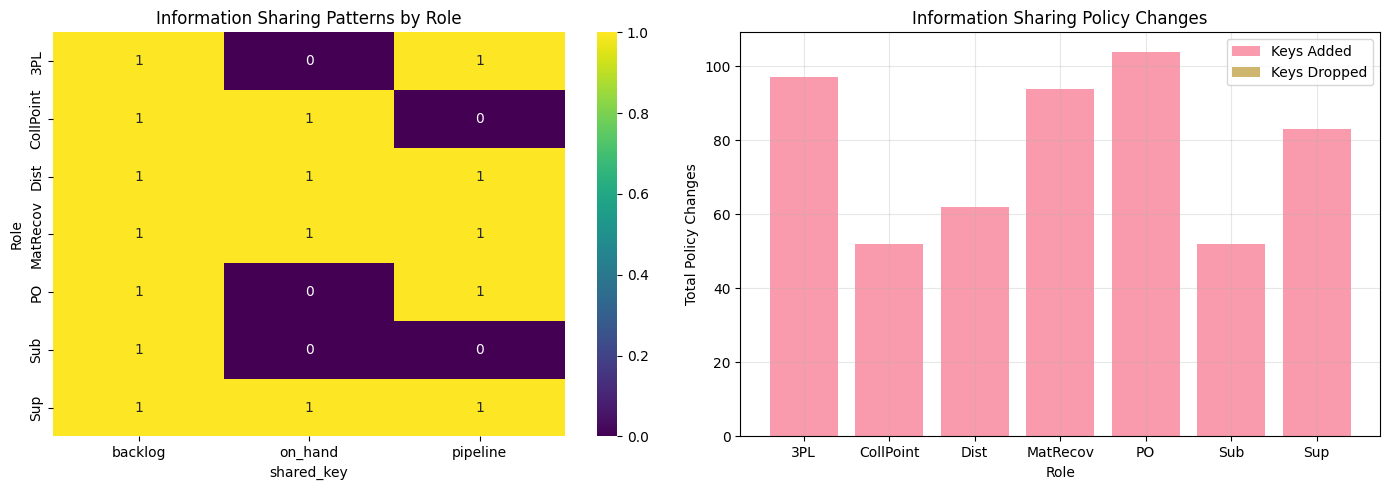

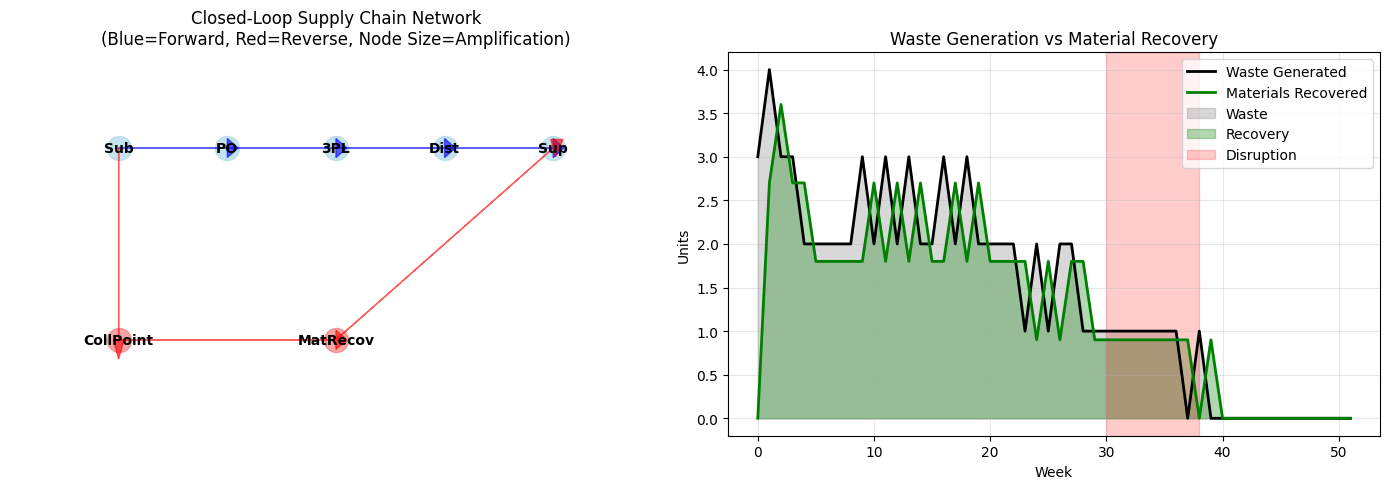

/tmp/ipython-input-1091179888.py:242: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([role_alphas[role] for role in all_roles if role in role_alphas],


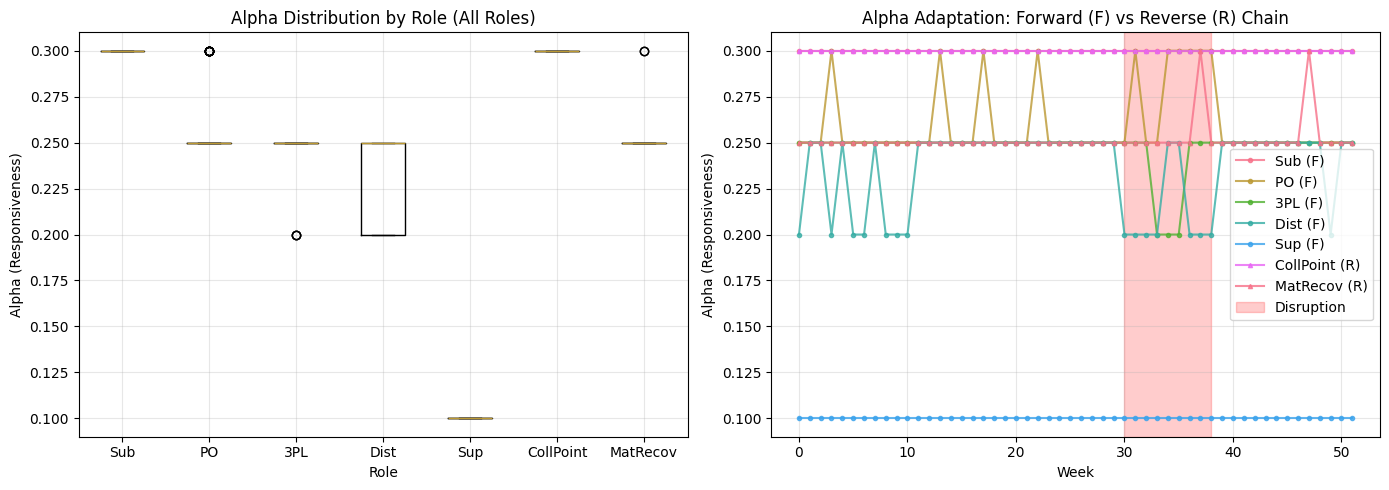

In [8]:
# ===== Comprehensive Visualizations for Closed-Loop Construction Supply Chain Research =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# Set style for publication-quality plots
plt.style.use('default')
sns.set_palette("husl")

# 1) BULLWHIP CASCADE ANALYSIS - Extended for closed-loop
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Forward chain bullwhip ratios with network distance
forward_roles_ordered = ["Sub", "PO", "3PL", "Dist", "Sup"]
forward_bullwhip = [df_kpi_forward[df_kpi_forward["role"] == r]["bullwhip_ratio_var"].iloc[0] for r in forward_roles_ordered]
network_distances = [0, 1, 2, 3, 4]

ax1.plot(network_distances, forward_bullwhip, 'o-', linewidth=3, markersize=8, color='steelblue', label='Forward Chain')
ax1.set_xlabel('Network Distance from Demand Source (Sub)')
ax1.set_ylabel('Bullwhip Ratio (Variance Amplification)')
ax1.set_title('Bullwhip Amplification by Network Position')
ax1.set_xticks(network_distances)
ax1.set_xticklabels(forward_roles_ordered)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='No Amplification')
ax1.legend()

# Mean vs Standard Deviation scatter for forward chain
for i, role in enumerate(forward_roles_ordered):
    row = df_kpi_forward[df_kpi_forward["role"] == role].iloc[0]
    ax2.scatter(row["bullwhip_ratio_var"], row["amplification_std"],
               s=200, alpha=0.7, label=role)
    ax2.annotate(role, (row["bullwhip_ratio_var"], row["amplification_std"]),
                xytext=(5, 5), textcoords='offset points')

# Add reverse chain if available
if len(df_kpi_reverse) > 0:
    for i, row in df_kpi_reverse.iterrows():
        ax2.scatter(row["processing_ratio_var"], row["processing_std"],
                   s=200, alpha=0.7, marker='^', label=f"{row['role']} (Reverse)")
        ax2.annotate(f"{row['role']}", (row["processing_ratio_var"], row["processing_std"]),
                    xytext=(5, 5), textcoords='offset points')

ax2.set_xlabel('Variance Amplification Ratio')
ax2.set_ylabel('Standard Deviation Amplification')
ax2.set_title('Variance vs Standard Deviation Amplification')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# 2) COEFFICIENT CHOICE HEATMAP BY ROLE - Extended for 7 roles
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Alpha choices
alpha_pivot = alpha_dist.pivot(index="role", columns="alpha", values="count").fillna(0).astype(int)
sns.heatmap(alpha_pivot, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Alpha Choices by Role (Demand Responsiveness)')
ax1.set_ylabel('Role')

# Service level choices
sl_pivot = sl_dist.pivot(index="role", columns="service_level", values="count").fillna(0).astype(int)
sns.heatmap(sl_pivot, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('Service Level Choices by Role (Safety Stock)')
ax2.set_ylabel('')

# Lot multiplier choices
lot_pivot = lot_dist.pivot(index="role", columns="lot_multiplier", values="count").fillna(0).astype(int)
sns.heatmap(lot_pivot, annot=True, fmt='d', cmap='Oranges', ax=ax3)
ax3.set_title('Lot Multiplier Choices by Role (Order Sizing)')
ax3.set_ylabel('Role')

# Expedite choices
exp_pivot = exp_dist.pivot(index="role", columns="expedite", values="count").fillna(0).astype(int)
sns.heatmap(exp_pivot, annot=True, fmt='d', cmap='Reds', ax=ax4)
ax4.set_title('Expedite Choices by Role (Rush Orders)')
ax4.set_ylabel('')

plt.tight_layout()
plt.show()

# 3) TIME SERIES DECOMPOSITION WITH DISRUPTION - Dual flow (Forward + Reverse)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))

t_idx = np.arange(len(customerDemand))
disruption_start = 30
disruption_end = 38

# Forward chain orders over time
ax1.plot(t_idx, customerDemand, 'k-', linewidth=2, label='Project Demand', alpha=0.8)
for role in forward_roles_ordered:
    ax1.plot(t_idx, hist_roles["orders_out"][role], label=f'{role} Orders', alpha=0.7)
ax1.axvspan(disruption_start, disruption_end, alpha=0.2, color='red', label='Disruption Period')
ax1.set_title('Forward Chain: Orders Over Time')
ax1.set_xlabel('Time (weeks)')
ax1.set_ylabel('Units')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# Reverse chain processing over time
ax2.plot(t_idx, projectWaste, 'k-', linewidth=2, label='Waste Generated', alpha=0.8)
reverse_roles = [r for r in ["CollPoint", "MatRecov"] if r in ROLES]
for role in reverse_roles:
    ax2.plot(t_idx, hist_roles["orders_out"][role], label=f'{role} Processing', alpha=0.7)
ax2.axvspan(disruption_start, disruption_end, alpha=0.2, color='red')
ax2.set_title('Reverse Chain: Waste Processing Over Time')
ax2.set_xlabel('Time (weeks)')
ax2.set_ylabel('Units')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

# Inventory levels over time (all roles)
all_roles = forward_roles_ordered + reverse_roles
for role in all_roles:
    ax3.plot(t_idx, hist_roles["on_hand"][role], label=f'{role} Inventory', alpha=0.7)
ax3.axvspan(disruption_start, disruption_end, alpha=0.2, color='red')
ax3.set_title('Inventory Levels Over Time (All Roles)')
ax3.set_xlabel('Time (weeks)')
ax3.set_ylabel('Units')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(True, alpha=0.3)

# Rolling variance (bullwhip over time)
window = 10
for role in all_roles:
    rolling_var = pd.Series(hist_roles["orders_out"][role]).rolling(window).var()
    ax4.plot(t_idx, rolling_var, label=f'{role} Rolling Variance', alpha=0.7)
ax4.axvspan(disruption_start, disruption_end, alpha=0.2, color='red')
ax4.set_title(f'Rolling Variance (Window={window} weeks)')
ax4.set_xlabel('Time (weeks)')
ax4.set_ylabel('Variance')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4) INFORMATION SHARING ANALYSIS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Current sharing policy by role
sharing_data = []
for role in ROLES:
    for key in current_share[role]:
        sharing_data.append({"role": role, "shared_key": key})
sharing_df = pd.DataFrame(sharing_data)

if not sharing_df.empty:
    sharing_counts = sharing_df.groupby(["role", "shared_key"]).size().reset_index(name="count")
    sharing_pivot = sharing_counts.pivot(index="role", columns="shared_key", values="count").fillna(0).astype(int)
    sns.heatmap(sharing_pivot, annot=True, fmt='d', cmap='viridis', ax=ax1)
ax1.set_title('Information Sharing Patterns by Role')
ax1.set_ylabel('Role')

# Sharing policy changes over time
ax2.bar(df_policy["role"], df_policy["share_add_total"], alpha=0.7, label='Keys Added')
ax2.bar(df_policy["role"], df_policy["share_drop_total"], alpha=0.7, label='Keys Dropped')
ax2.set_title('Information Sharing Policy Changes')
ax2.set_xlabel('Role')
ax2.set_ylabel('Total Policy Changes')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5) CLOSED-LOOP NETWORK STRUCTURE VISUALIZATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Position nodes for closed-loop network
positions = {
    "Sub": (2, 2), "PO": (3, 2), "3PL": (4, 2), "Dist": (5, 2), "Sup": (6, 2),
    "CollPoint": (2, 1), "MatRecov": (4, 1)
}

# Create combined bullwhip dict
bullwhip_dict = dict(zip(forward_roles_ordered, forward_bullwhip))
if len(df_kpi_reverse) > 0:
    for _, row in df_kpi_reverse.iterrows():
        bullwhip_dict[row["role"]] = row["processing_ratio_var"]

# Draw network nodes
for role, (x, y) in positions.items():
    if role in bullwhip_dict:
        size = max(300, bullwhip_dict[role] * 50)
        color = 'lightblue' if role in forward_roles_ordered else 'lightcoral'
        ax1.scatter(x, y, s=size, alpha=0.7, color=color, label=f'{role} ({bullwhip_dict[role]:.1f}x)')
        ax1.annotate(role, (x, y), ha='center', va='center', fontweight='bold')

# Draw connections - forward chain
forward_connections = [("Sub", "PO"), ("PO", "3PL"), ("3PL", "Dist"), ("Dist", "Sup")]
for start, end in forward_connections:
    x1, y1 = positions[start]
    x2, y2 = positions[end]
    ax1.arrow(x1, y1, x2-x1, y2-y1, head_width=0.1, head_length=0.1, fc='blue', ec='blue', alpha=0.6)

# Draw connections - reverse chain
reverse_connections = [("Sub", "CollPoint"), ("CollPoint", "MatRecov"), ("MatRecov", "Sup")]
for start, end in reverse_connections:
    if start in positions and end in positions:
        x1, y1 = positions[start]
        x2, y2 = positions[end]
        ax1.arrow(x1, y1, x2-x1, y2-y1, head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.6)

ax1.set_title('Closed-Loop Supply Chain Network\n(Blue=Forward, Red=Reverse, Node Size=Amplification)')
ax1.set_xlim(1, 7)
ax1.set_ylim(0.5, 2.5)
ax1.axis('off')

# Closed-loop efficiency analysis
if "waste_in" in hist_roles:
    waste_generated = hist_roles["waste_in"]["Sub"]
    materials_recovered = hist_roles["orders_out"]["MatRecov"] if "MatRecov" in hist_roles["orders_out"] else np.zeros_like(waste_generated)

    ax2.plot(t_idx, waste_generated, 'black', linewidth=2, label='Waste Generated')
    ax2.plot(t_idx, materials_recovered, 'green', linewidth=2, label='Materials Recovered')
    ax2.fill_between(t_idx, 0, waste_generated, alpha=0.3, color='gray', label='Waste')
    ax2.fill_between(t_idx, 0, materials_recovered, alpha=0.3, color='green', label='Recovery')
    ax2.axvspan(disruption_start, disruption_end, alpha=0.2, color='red', label='Disruption')
    ax2.set_title('Waste Generation vs Material Recovery')
    ax2.set_xlabel('Week')
    ax2.set_ylabel('Units')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6) ROLE-SPECIFIC ALPHA STRATEGIES - Extended for closed-loop
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Alpha distribution by role (all roles)
role_alphas = {}
for role in all_roles:
    if role in coeff_logs:
        role_alphas[role] = [c["alpha"] for c in coeff_logs[role]]

if role_alphas:
    ax1.boxplot([role_alphas[role] for role in all_roles if role in role_alphas],
                labels=[role for role in all_roles if role in role_alphas])
    ax1.set_title('Alpha Distribution by Role (All Roles)')
    ax1.set_ylabel('Alpha (Responsiveness)')
    ax1.set_xlabel('Role')
    ax1.grid(True, alpha=0.3)

# Alpha evolution during disruption (separate for forward/reverse)
for role in forward_roles_ordered:
    if role in coeff_logs:
        times = [c["t"] for c in coeff_logs[role]]
        alphas = [c["alpha"] for c in coeff_logs[role]]
        ax2.plot(times, alphas, 'o-', label=f'{role} (F)', alpha=0.8, markersize=3)

for role in reverse_roles:
    if role in coeff_logs:
        times = [c["t"] for c in coeff_logs[role]]
        alphas = [c["alpha"] for c in coeff_logs[role]]
        ax2.plot(times, alphas, '^-', label=f'{role} (R)', alpha=0.8, markersize=3)

ax2.axvspan(disruption_start, disruption_end, alpha=0.2, color='red', label='Disruption')
ax2.set_title('Alpha Adaptation: Forward (F) vs Reverse (R) Chain')
ax2.set_xlabel('Week')
ax2.set_ylabel('Alpha (Responsiveness)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 echelon role  YOURS_OrVrR  ABM_MA4_OrVrR  ABM_MA6_OrVrR  ABM_MA8_OrVrR
       0  Sub        1.000          1.892          1.523          1.480
       1   PO        0.549          3.921          2.691          2.477
       2  3PL        0.342          7.565          4.514          3.799
       3 Dist        0.367         25.464         11.471          8.456
       4  Sup        0.404         51.508         19.928         13.104


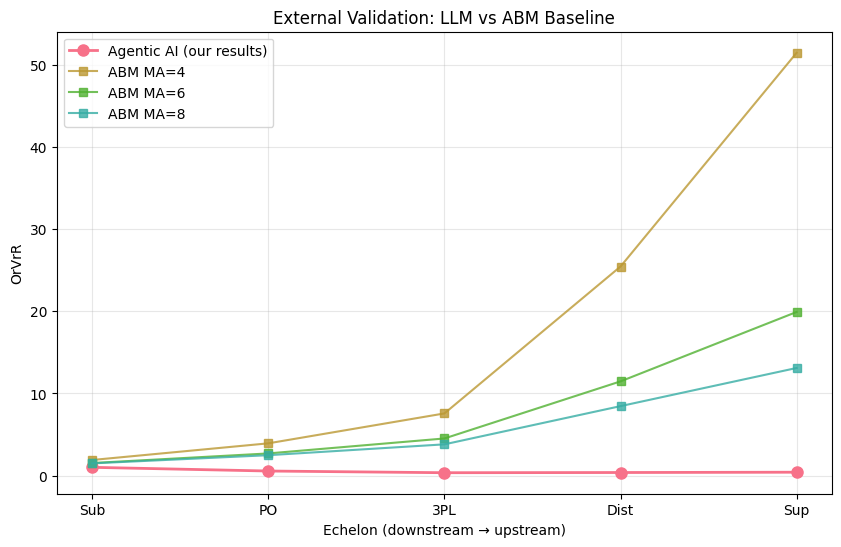

In [9]:
# === ABM-style comparator (Chinh et al. flavor): MA forecast, OUT with protection L+1 ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
roles = ["Sub","PO","3PL","Dist","Sup"]  # Updated for 6-role chain

# your data
ORD = np.vstack([np.asarray(hist_roles["orders_out"][r], float) for r in roles])
DEMAND = np.asarray(customerDemand, float).ravel()
E, T = ORD.shape; assert DEMAND.size == T
warmup = max(5, int(0.2*T)); eff = slice(warmup, T)
varD = float(np.var(DEMAND[eff])); YOUR = np.var(ORD[:, eff], axis=1)/max(varD,1e-12)

# per-echelon LT (edit to match your InfoBank lead times)
L_vec = np.array([1.0, 1.0, 1.0, 3.0, 1.0], dtype=float)  # Sub, PO, 3PL, Dist, Sup
Lp = L_vec + 1.0

def simulate_abm_ma(d, L_vec, m_win=6, cap_vec=None, clamp_nonneg=True):
    """5-agent chain; MA(m) forecast; OUT target S=mu*(L+1); z=0; nonnegative orders; optional uniform/per-echelon caps."""
    d = np.asarray(d, float).ravel()
    E = len(L_vec); T = d.size; Lp = L_vec + 1.0
    # init
    mu0 = float(np.mean(d[:max(8, warmup)]))
    mu = np.full(E, mu0)
    on = np.zeros(E); bk = np.zeros(E); inbound = [dict() for _ in range(E)]
    # steady-state inbound so inv position ~ S0
    S0 = mu*Lp
    for j in range(E):
        L0 = int(round(L_vec[j])); q_each = (S0[j]/max(L0,1)) if L0>0 else S0[j]
        if L0 == 0:
            on[j] += S0[j]  # zero LT: hold on-hand
        else:
            for u in range(1, L0+1): inbound[j][u] = inbound[j].get(u,0.0)+q_each
        if j==E-1:
            if L0 == 0:
                on[j] += S0[j]
            else:
                for u in range(1, L0+1): inbound[j][u] = inbound[j].get(u,0.0)+q_each

    def recv(t):
        for j in range(E):
            if t in inbound[j]: on[j] += inbound[j].pop(t)

    def ship(u,v,q,t):
        if q<=0: return
        lt = int(round(L_vec[u])); due = t + max(lt,0)
        inbound[v][due] = inbound[v].get(due,0.0) + q

    # rolling MA buffers per echelon's incoming demand stream
    from collections import deque
    buf = [deque(maxlen=m_win) for _ in range(E)]
    buf[0].append(max(d[0],0.0))
    for j in range(1,E): buf[j].append(0.0)

    orders = np.zeros((E,T))
    for t in range(T):
        recv(t)
        # compute MA forecasts for protection period
        mu_ma = np.zeros(E)
        for j in range(E):
            mu_ma[j] = (np.mean(buf[j]) if len(buf[j])>0 else mu0)

        # implicit OUT recurrence: q_t = (S_t - S_{t-1}) + incoming_{t-1}
        S_t = mu_ma * Lp
        if t == 0:
            q_row = np.zeros(E)
        else:
            q_row = (S_t - S_prev)
            q_row[0] += max(d[t-1],0.0)
            for j in range(1,E):
                q_row[j] += orders[j-1, t-1]

        # clamp & caps
        cap = None
        if cap_vec is not None:
            cap = np.asarray(cap_vec, float)
            if cap.size == 1: cap = np.repeat(float(cap), E)
        for j in range(E):
            q = q_row[j]
            if clamp_nonneg and q < 0: q = 0.0
            if cap is not None and np.isfinite(cap[j]): q = min(q, cap[j])
            orders[j, t] = q
            if j==E-1 and q>0: ship(j, j, q, t)

        # serve demand and push downstream shipments
        need0 = bk[0] + max(float(d[t]),0.0)
        sell0 = min(on[0], need0); on[0]-=sell0; bk[0]=need0-sell0
        for j in range(1,E):
            need = bk[j] + orders[j-1, t]
            shipq = min(on[j], need)
            on[j] -= shipq; bk[j] = need - shipq
            if shipq>0: ship(j, j-1, shipq, t)

        # update MA buffers with this period's incoming streams
        buf[0].append(max(d[t],0.0))
        for j in range(1,E): buf[j].append(orders[j-1, t])

        S_prev = S_t.copy()

    Or = np.var(orders[:, eff], axis=1) / max(np.var(d[eff]), 1e-12)
    return Or

# Try three MA windows (like three alphas): m in {4, 6, 8}
m_list = [4, 6, 8]
vecs = [simulate_abm_ma(DEMAND, L_vec, m_win=m, cap_vec=None, clamp_nonneg=True) for m in m_list]

# Table
tbl = pd.DataFrame({"echelon": range(E), "role": roles, "YOURS_OrVrR": YOUR})
for m, v in zip(m_list, vecs): tbl[f"ABM_MA{m}_OrVrR"] = v
print(tbl.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(E), YOUR, marker="o", label="Agentic AI (our results)", linewidth=2, markersize=8)
for m, v in zip(m_list, vecs):
    plt.plot(range(E), v, marker="s", label=f"ABM MA={m}", alpha=0.8)
plt.xticks(range(E), roles); plt.xlabel("Echelon (downstream → upstream)")
plt.ylabel("OrVrR"); plt.title(f"External Validation: LLM vs ABM Baseline")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()